<a href="https://colab.research.google.com/github/MakhamudDrame/ML_lab/blob/main/LAB_5_Linear_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### О ЛР:

- подкапотное представление SVM и логистической регресии
- Калибровка вероятностей, калибровочные кривые
- Feature Enginnering (отбор признаков, счетчики)
- Экономический эффект модели от внедрения в боевой режим




## Инструкция по сдаче ДЗ.



0. Просмотр лекции обязателен. Не потому что без этого невозможно выполнить домашнее задание, а потому что с этим выполнение домашнего задания станет комфортным, приятным и быстрым. Вы потратите намного меньше времени для изучения материала и понимания того, что от Вас хотят, нежели сразу приступите к выполнению домашнего задания без просмотра лекции.

1. Скопируйте к себе колаб-ноутбук.

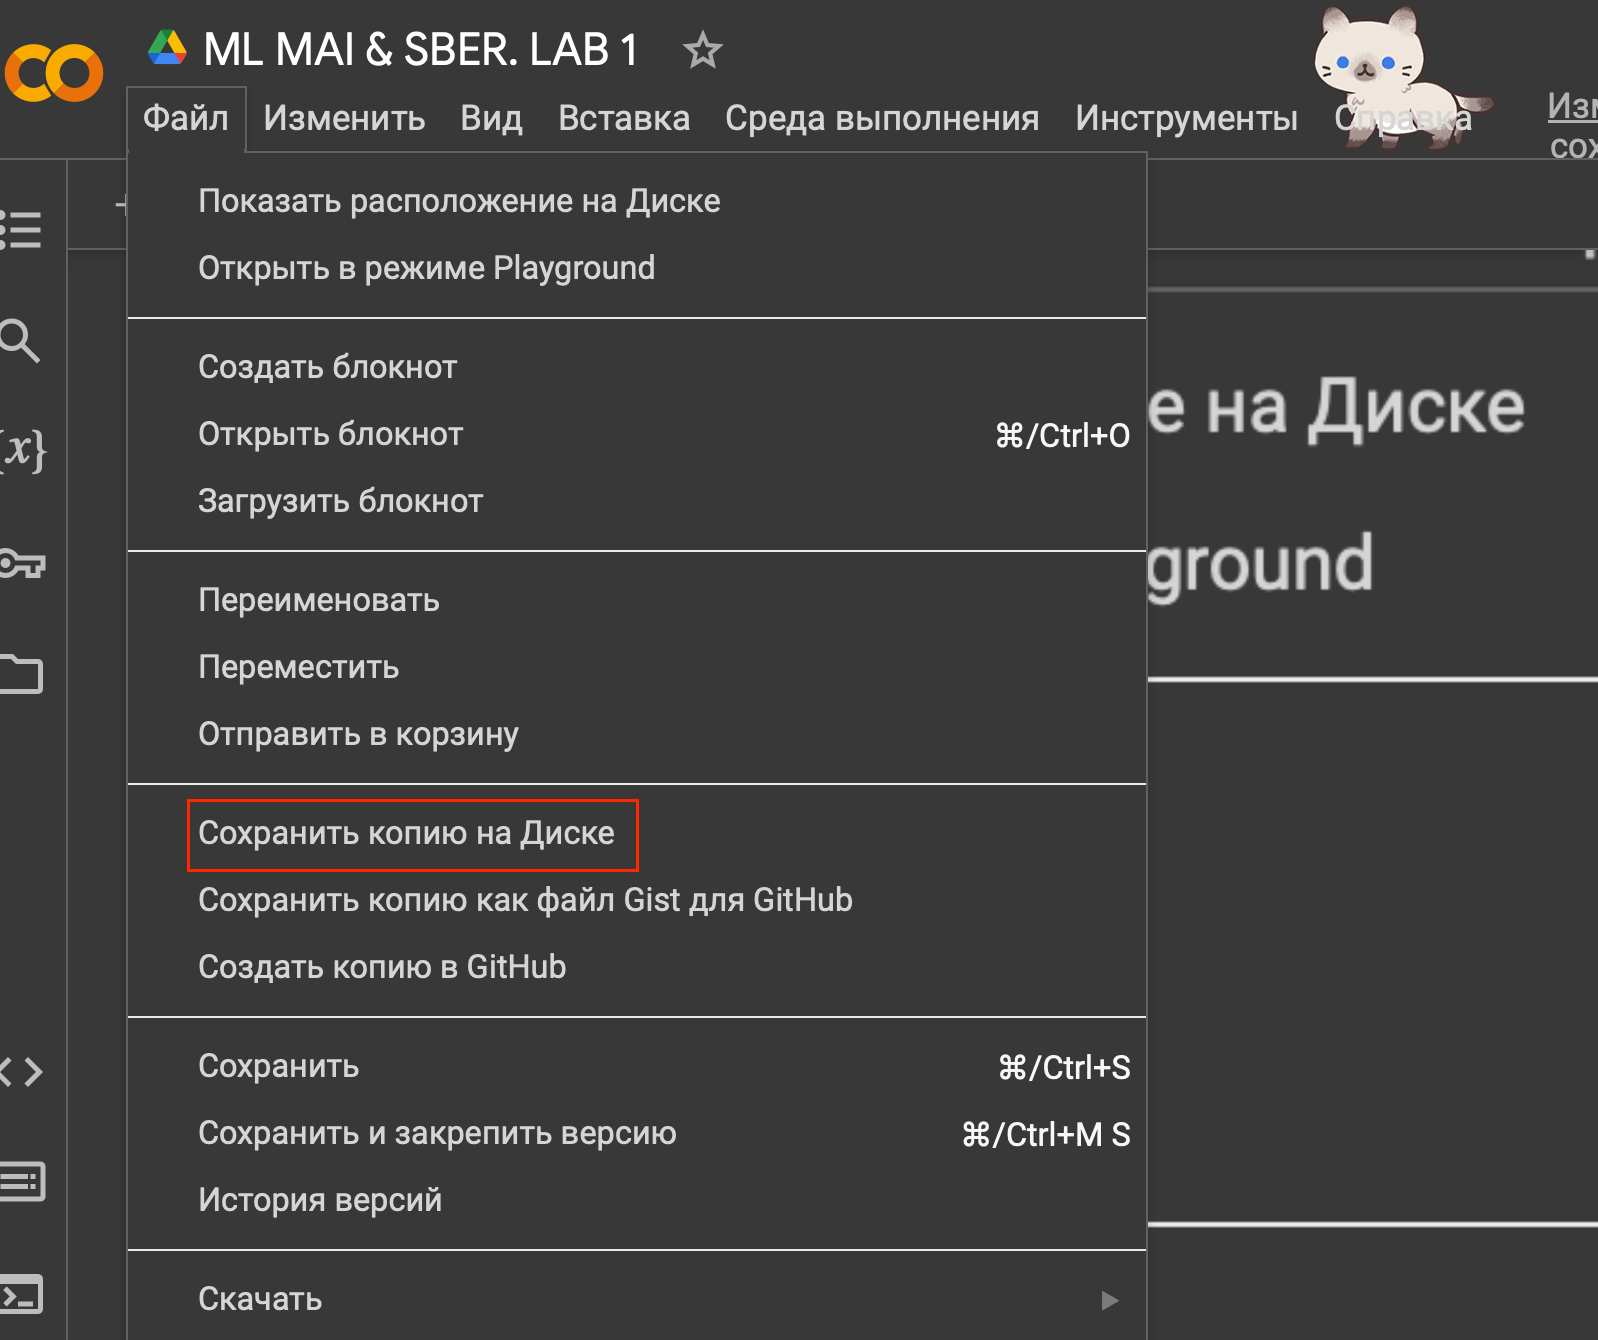

2. у Вас откроется файл в новой вкладке с названием "Копия...". После описания задания вы пишите решение этого задания.

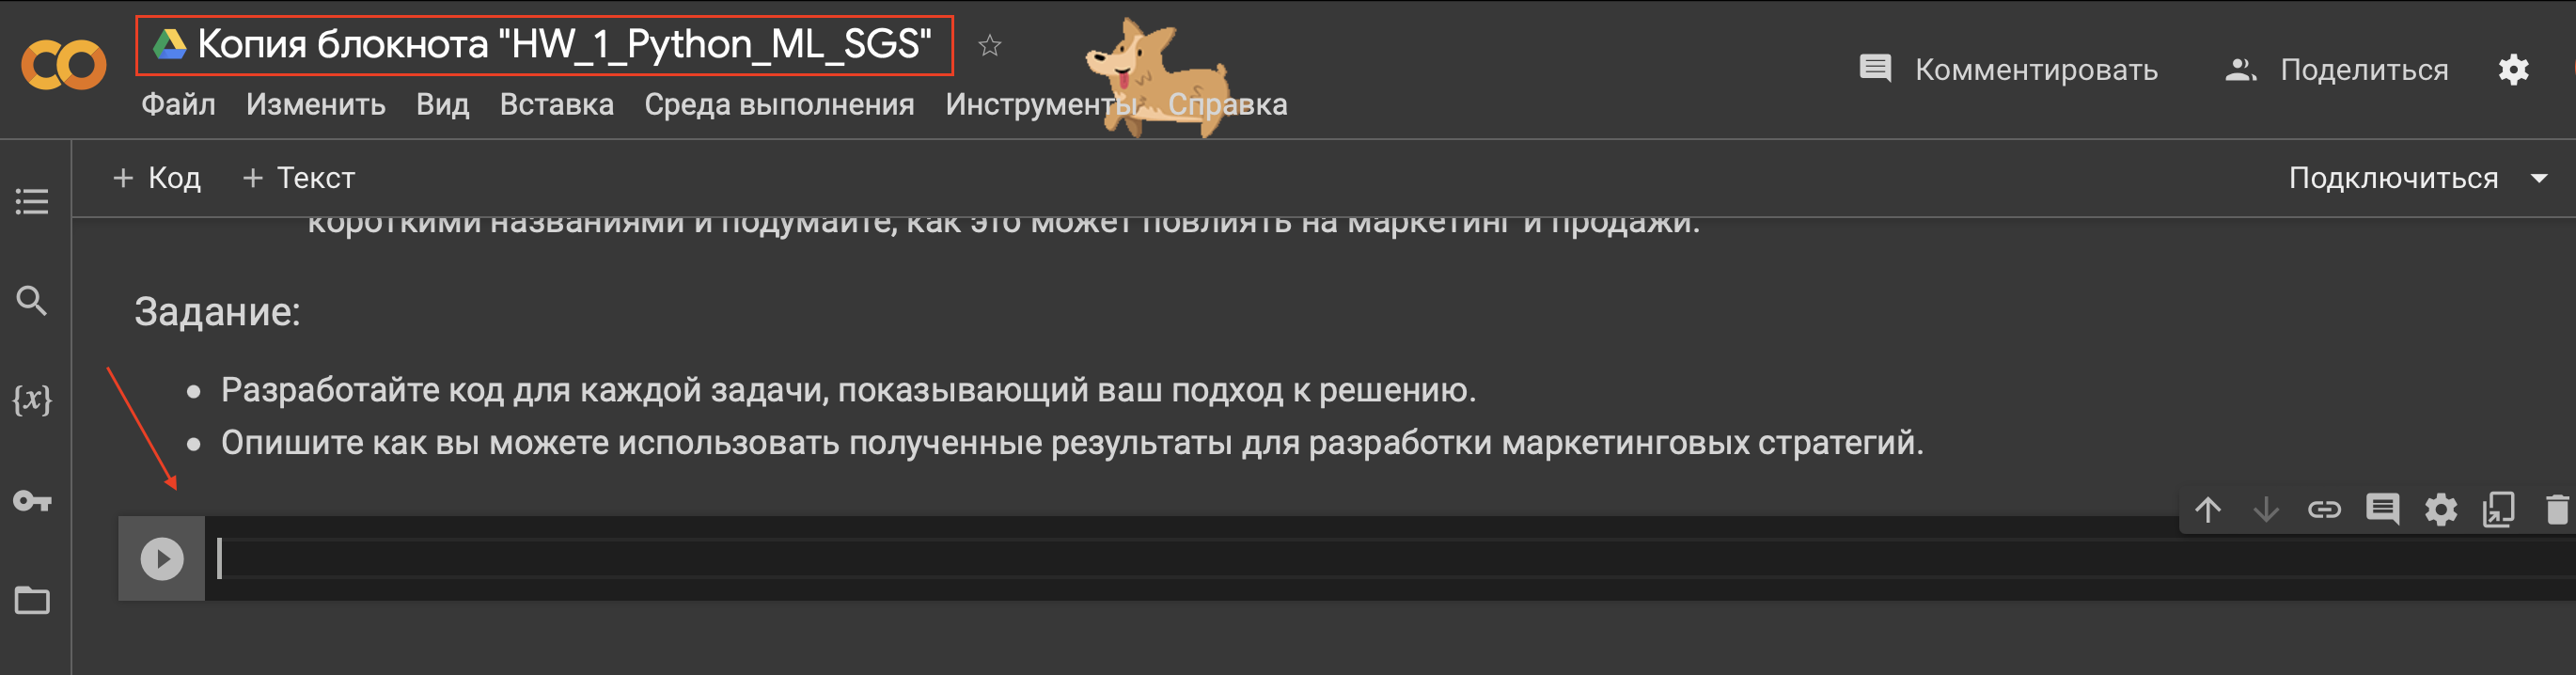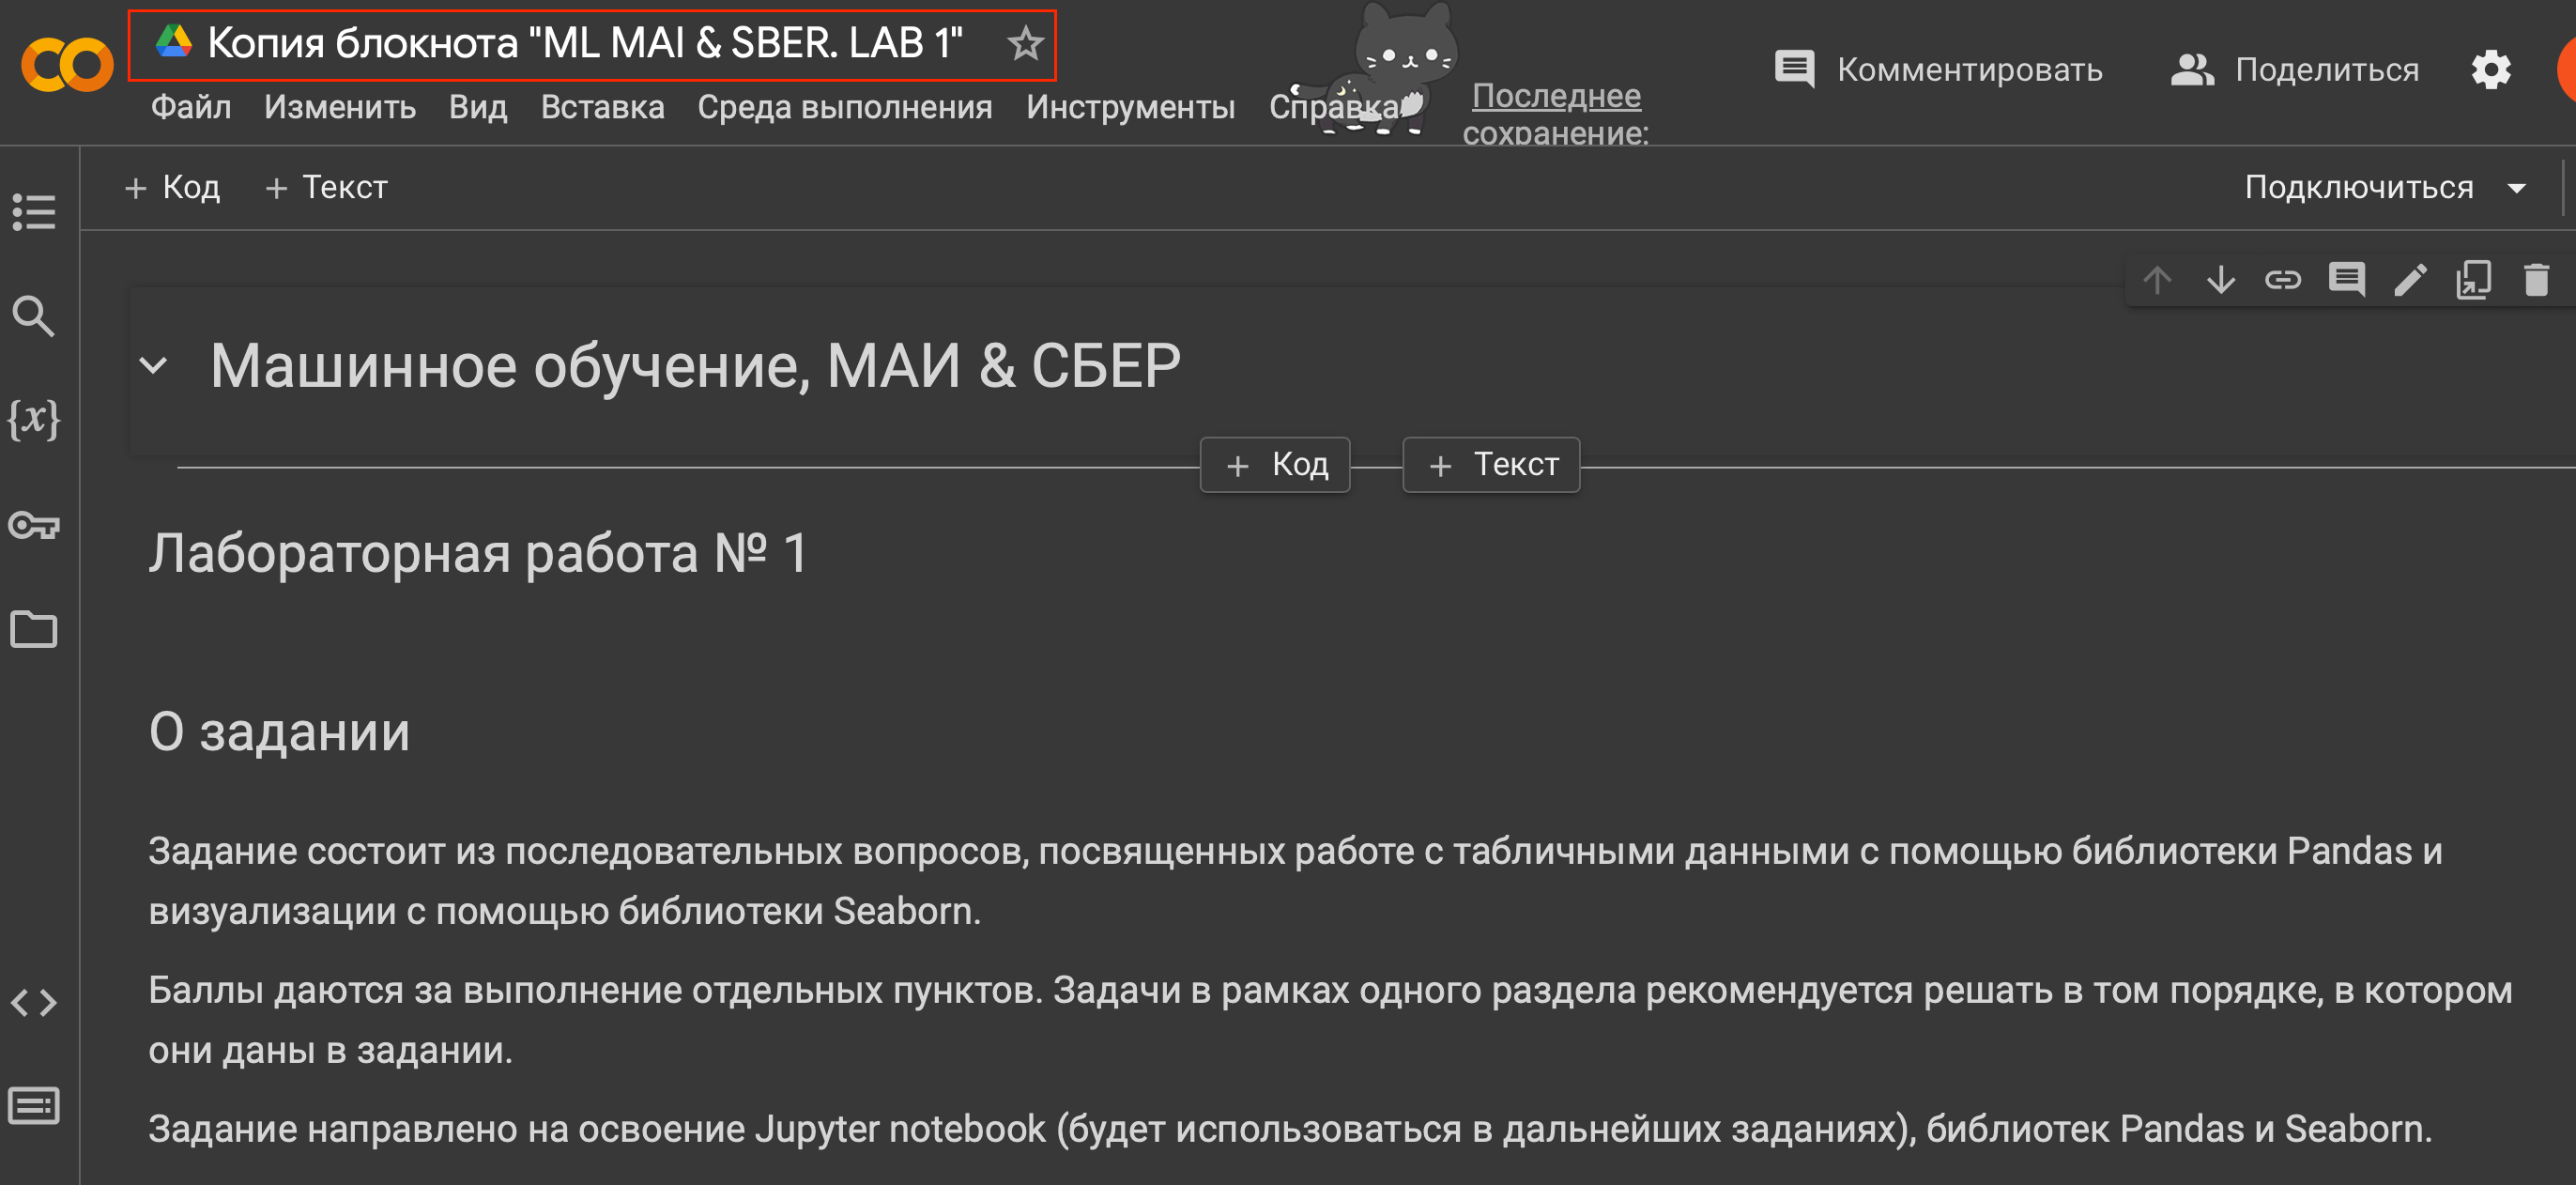

3. После выполнения домашнего задания нажмите кнопку "поделиться" и перейдите в режим доступно всем по ссылке

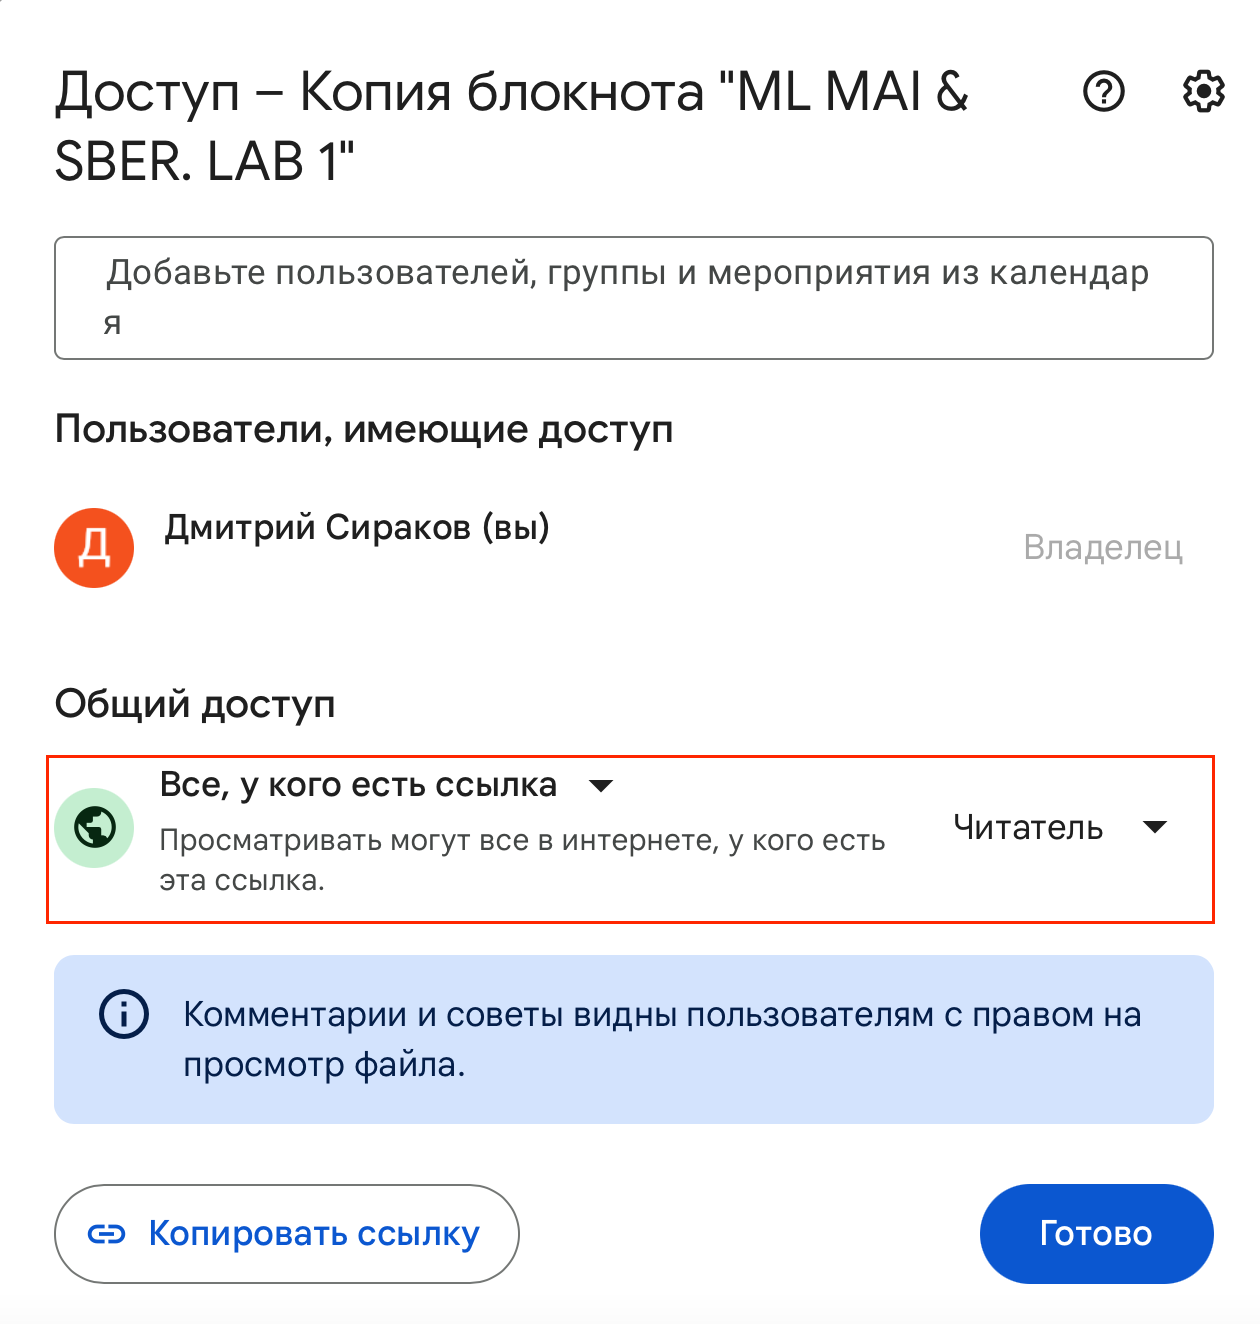

4. Загрузите эту ссылку в lms.mai.ru по курсу "Машинное обучение" в качестве ссылки в раздел "Линейная классификация с Scikit-learn и Seaborn для визуализации (ЛР)[06.04]"


## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 5 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты не могут получить за него больше 0 баллов.

Неэффективная реализация кода может негативно отразиться на оценке.

# Часть 1. SVM, LR и калибровка вероятностей (1.25 балла)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

#### __Задание 1.1  Сравнение методов__ (0.25 балла)



Сгенерируем синтетические данные.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# фиксируем random_state для воспроизводимости результатов
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

__Случайный классификатор__

Для начала зададим самую простую модель, которая на каждом объекте выдаёт случайный ответ. По тестовой выборке вычислим AUC-ROC, AUC-PR.

**AUC-ROC**:
- ROC-кривая (Receiver Operating Characteristic curve) - это график, который показывает производительность классификационной модели при всех пороговых значениях классификации. Она изображает две величины: True Positive Rate (TPR, чувствительность) и False Positive Rate (FPR, 1-специфичность).
- AUC (Area Under the Curve) - это площадь под ROC-кривой. Значение AUC лежит в диапазоне от 0 до 1. Модель с AUC, равным 1, является идеальным классификатором, а модель с AUC, равным 0.5, не имеет классификационной способности.

**AUC-PR**:
- PR-кривая (Precision-Recall curve) - это график, который показывает зависимость точности (precision) от полноты (recall) для различных пороговых значений.
- AUC-PR также является площадью под PR-кривой. Эта метрика особенно полезна в случаях, когда классы сильно несбалансированы. Максимальное значение AUC-PR равно 1, что означает идеальную классификацию, а минимальное значение зависит от соотношения классов в данных.

In [ ]:
from sklearn.dummy import DummyClassifier
random_classifier = DummyClassifier(strategy='uniform', random_state=42).fit(X_train, y_train)
y_random = random_classifier.predict_proba(X_test)[:,1]
y_random

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5])

**Вопрос:** решаем задачу бинарной классификации, но y\_random содержит какие-то дробные числа, а не 0/1. Почему?



Метод predict_proba(), который возвращает вероятности принадлежности к классам 0 и 1, здесь выведена вероятность принадлежности к 1 классу

*Ниже приведен **пример** работы* со встроенными функциями `sklearn` для отрисовки ROC и PR кривых, сохранения метрик. Пайплайн можно изменять как вам удобно.

In [ ]:
from sklearn.metrics import auc
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score

Random Classifier metrics
AUC-PR: 0.75283
AUC-ROC: 0.50000


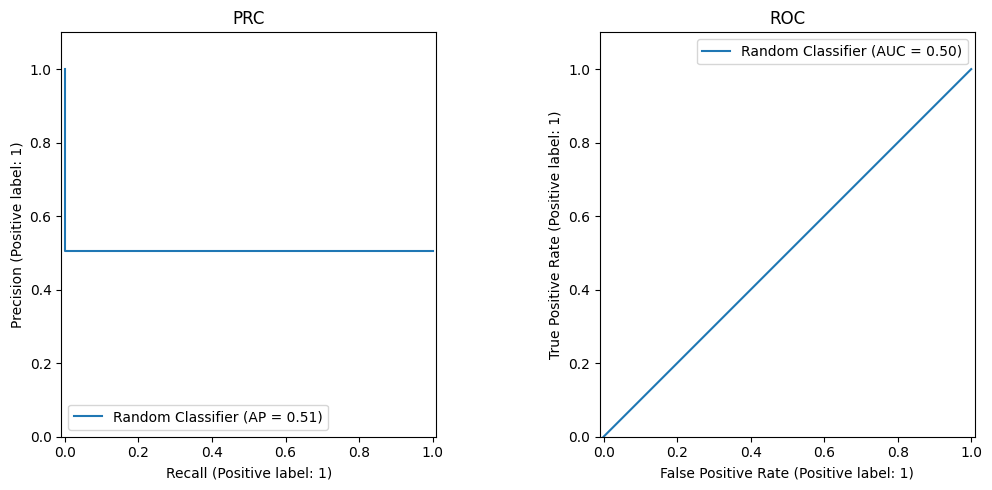

In [ ]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
  if ax is None:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

  print(classifier_name, 'metrics')
  PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
  precision, recall, _ = precision_recall_curve(y_true, y_pred)
  print('AUC-PR: %.5f' % auc(recall, precision))
  ax[0].set_title("PRC")
  ax[0].set_ylim(0, 1.1)

  RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
  print('AUC-ROC: %.5f' % roc_auc_score(y_true, y_pred))
  ax[1].set_title("ROC")
  ax[1].set_ylim(0, 1.1)

  plt.tight_layout()
  plt.legend()


depict_pr_roc(y_test, y_random, 'Random Classifier')

In [ ]:
# dataframe для сравнения
# методов классификации по метрикам
df_metrics = pd.DataFrame(columns=['AUC_PR', 'AUC_ROC', 'reg_const'])
precision, recall, _ = precision_recall_curve(y_test, y_random)
  # добавление очередной строки с характеристиками метода
df_metrics.loc['Random Classifier'] = [
      auc(recall, precision),
      roc_auc_score(y_test, y_random),
      0
]

  # по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,AUC_PR,AUC_ROC,reg_const
Random Classifier,0.752833,0.5,0.0


__Support Vector Machine (Linear Kernel)__

Обучите метод опорных векторов.

На занятиях мы проходили линейный вариант без ядрового перехода, что соответствует линейному ядру (`LinearSVC` или же `SVC(kernel='linear')` в `sklearn.svm`).

Подберите параметр регуляризации `C` с точки зрения AUC-PR (можете воспользоваться кросс-валидацией или отделить валидационную выборку от обучающей).


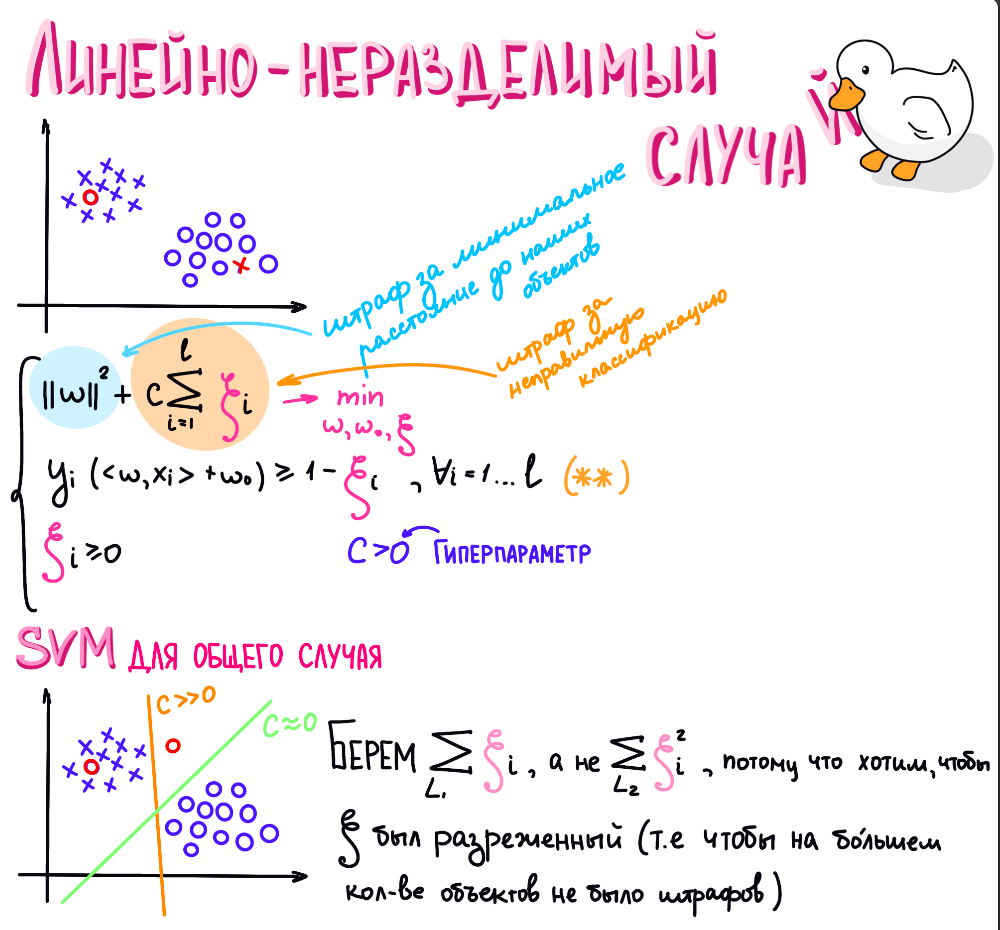

In [ ]:
from sklearn.svm import SVC

# Разделим трейн
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

# Значения C для перебора
C_values = np.logspace(-4, 1, num=50)
best_auc_pr = -np.inf
best_C = None

# Подбор параметра C
for C in C_values:
    model = SVC(
        kernel='linear',
        C=C,
        probability=True,
        random_state=42
    ).fit(X_train_sub, y_train_sub)

    # Прогноз вероятностей на валидации
    y_proba = model.predict_proba(X_val)[:, 1]

    # Расчет AUC-PR
    current_auc_pr = average_precision_score(y_val, y_proba)

    # Обновление лучшего параметра
    if current_auc_pr > best_auc_pr:
        best_auc_pr = current_auc_pr
        best_C = C

# Обучение финальной модели с лучшим C на полных данных
best_svm = SVC(
    kernel='linear',
    C=best_C,
    probability=True,
    random_state=42
).fit(X_train, y_train)

# Прогноз вероятностей на валидации
y_proba_val = best_svm.predict_proba(X_val)[:, 1]
print(f'Best C: ',{best_C})
y_proba_val

Best C:  {np.float64(0.0001)}


array([0.13439831, 0.08178833, 0.54052593, ..., 0.58888513, 0.15978711,
       0.15988928])

  На тестовой части:
  - постройте ROC и PR кривые,
  - посчитайте AUC-ROC, AUC-PR с точностью до 5 знаков

SVM Linear metrics
AUC-PR: 0.83312
AUC-ROC: 0.83987


,AUC_PR,AUC_ROC,reg_const
Random Classifier,0.75283,0.50000,0.0000
SVM Linear,0.83312,0.83987,0.0001


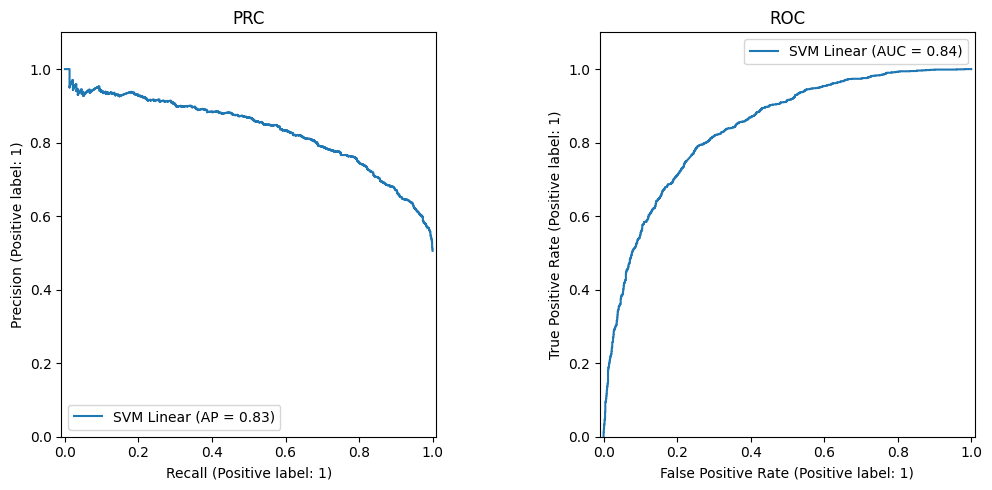

In [ ]:
# Прогноз вероятностей для тестовой выборки
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]

# Оценка метрик
auc_pr_svm = average_precision_score(y_test, y_proba_svm)
auc_roc_svm = roc_auc_score(y_test, y_proba_svm)


depict_pr_roc(y_test, y_proba_svm, 'SVM Linear')

# Добавление метрик SVM в DataFrame
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_proba_svm)
df_metrics.loc['SVM Linear'] = [
    auc(recall_svm, precision_svm),
    roc_auc_score(y_test, y_proba_svm),
    best_C
]


display(df_metrics.round(5))

Сравните AUC-ROC и AUC-PR для вашей модели с этими же метриками для случайного классификатора.

Random Classifier metrics
AUC-PR: 0.75283
AUC-ROC: 0.50000
SVM Linear metrics
AUC-PR: 0.83312
AUC-ROC: 0.83987


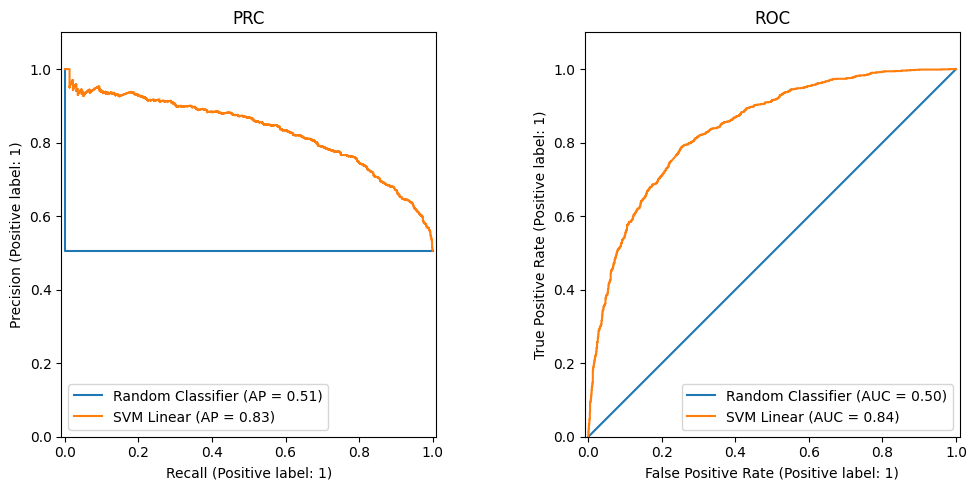

In [ ]:
# Построение PR и ROC кривых для SVM и случайного классификатора
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
depict_pr_roc(y_test, y_random, 'Random Classifier', ax=ax)
depict_pr_roc(y_test, y_proba_svm, 'SVM Linear', ax=ax)
plt.show()

__Logistic Regression__





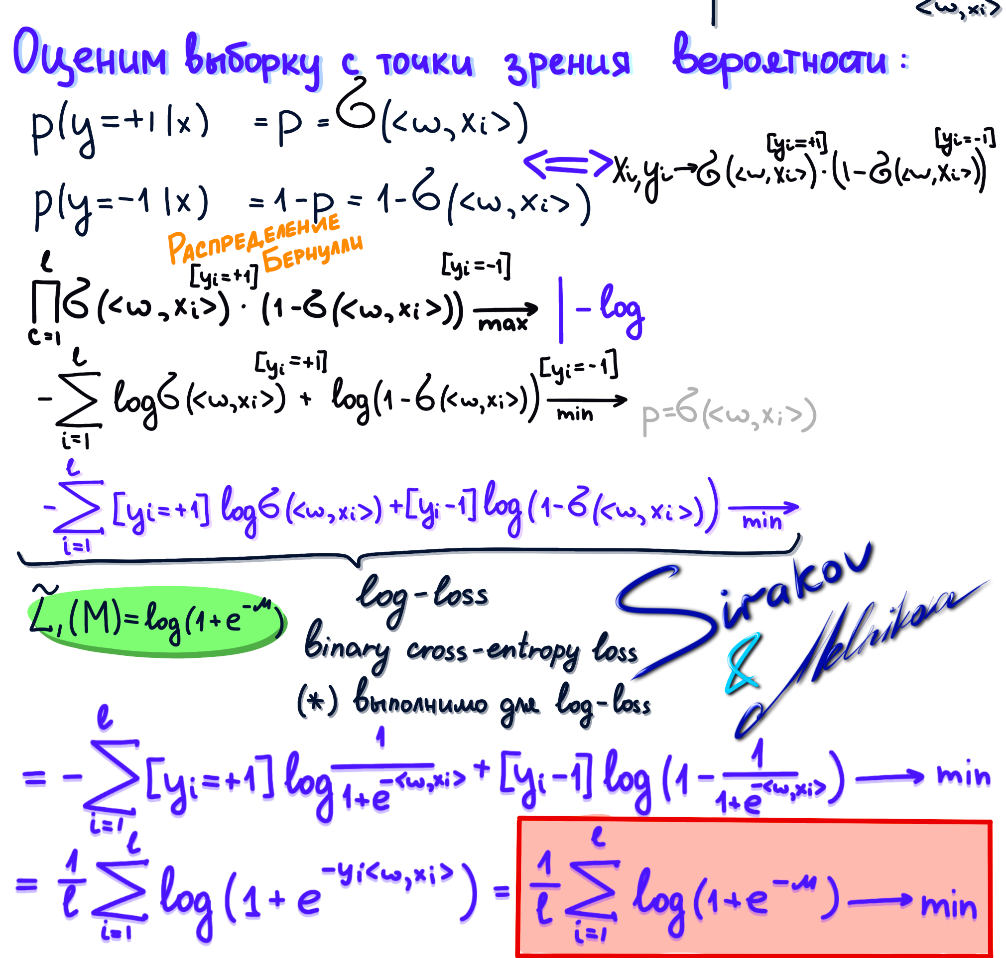

Давай проведем анализ эффективности логистической регрессии с регуляризацией L2 для бинарной классификации.

Вот наши шаги:

1. **Определение гиперпараметра C**: Начнем с подбора гиперпараметра C, который контролирует силу регуляризации в логистической регрессии. Для этого используем метрику AUC-PR, которая показывает баланс между точностью и полнотой. Выбор оптимального значения C поможет нам улучшить производительность модели, особенно в условиях несбалансированных данных.

2. **Визуализация кривых ROC и PR**: После того как мы определим наилучший гиперпараметр C, нарисуем ROC и PR кривые для тестовых данных. Эти кривые помогут нам оценить, насколько хорошо наша модель различает классы и как она справляется с балансом между точностью и полнотой.

3. **Оценка метрик**: Наконец, выведем ключевые метрики для тестовых данных, такие как AUC-ROC и AUC-PR, чтобы оценить производительность логистической регрессии. Сравним эти результаты с показателями случайного классификатора, чтобы понять, насколько наша модель превосходит случайное угадывание.


In [ ]:
from sklearn.linear_model import LogisticRegression


# Значения C для перебора
C_values = np.logspace(-4, 1, num=50)
best_auc_pr = -np.inf
best_C = None

# Подбор параметра C
for C in C_values:
    model = LogisticRegression(
        penalty='l2',
        C=C,
        solver='liblinear',
        random_state=42
    ).fit(X_train_sub, y_train_sub)

    # Прогноз на валидации
    y_proba = model.predict_proba(X_val)[:, 1]

    # Расчет AUC-PR
    current_auc_pr = average_precision_score(y_val, y_proba)

    # Обновление лучшего параметра
    if current_auc_pr > best_auc_pr:
        best_auc_pr = current_auc_pr
        best_C = C

# Обучение финальной модели с лучшим C
best_log = LogisticRegression(
    penalty='l2',
    C=best_C,
    solver='liblinear',
    random_state=42
).fit(X_train, y_train)


print(f'Best C: {best_C}')

Best C: 0.0001


,AUC_PR,AUC_ROC,reg_const
Random Classifier,0.75283,0.50000,0.0000
SVM Linear,0.83312,0.83987,0.0001
Logistic Regression,0.82961,0.83548,0.0001


Logistic Regression metrics
AUC-PR: 0.82961
AUC-ROC: 0.83548


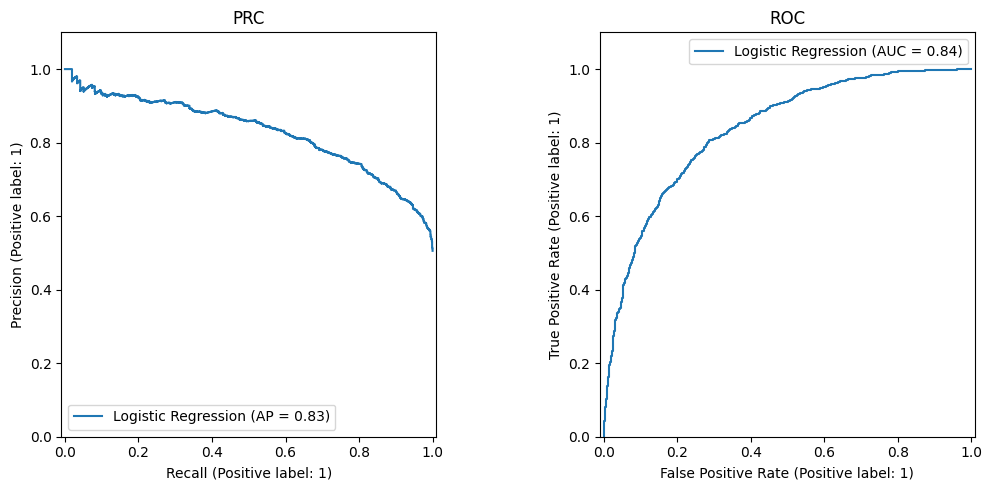

In [ ]:
y_proba_log = best_log.predict_proba(X_test)[:, 1]

# Оценка метрик
auc_pr_log = average_precision_score(y_test, y_proba_log)
auc_roc_log = roc_auc_score(y_test, y_proba_log)


# Добавление метрик в DataFrame
precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_log)
df_metrics.loc['Logistic Regression'] = [
    auc(recall_log, precision_log),
    auc_roc_log,
    best_C
]

display(df_metrics.round(5))


# Вызов функции для Logistic Regression
depict_pr_roc(y_test, y_proba_log, 'Logistic Regression')

Нарисуйте ROC, PR кривые для тестовой части для всех 3 классификаторов на одном графике

Random Classifier metrics
AUC-PR: 0.75283
AUC-ROC: 0.50000
SVM Linear metrics
AUC-PR: 0.83312
AUC-ROC: 0.83987
Logistic Regression metrics
AUC-PR: 0.82961
AUC-ROC: 0.83548


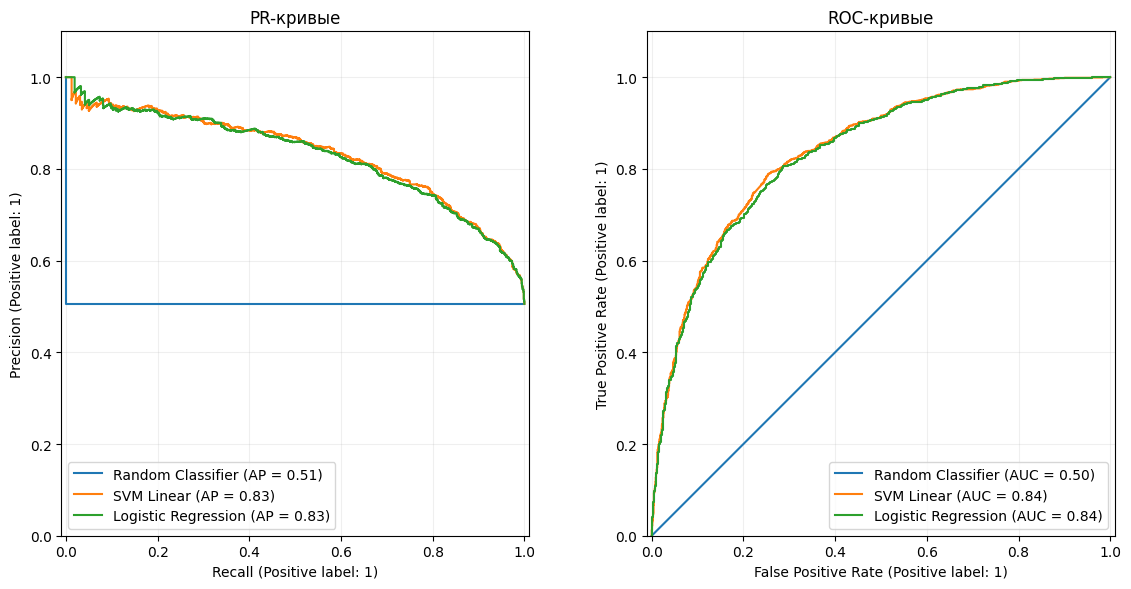

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Отображение всех классификаторов на одних осях
depict_pr_roc(y_test, y_random, 'Random Classifier', ax=ax)
depict_pr_roc(y_test, y_proba_svm, 'SVM Linear', ax=ax)
depict_pr_roc(y_test, y_proba_log, 'Logistic Regression', ax=ax)


# Настройки графиков
ax[0].set_title("PR-кривые", fontsize=12)
ax[1].set_title("ROC-кривые", fontsize=12)
ax[0].grid(alpha=0.2)
ax[1].grid(alpha=0.2)

**Вопрос:** Сравните результаты LR и SVM с точки зрения всех вычисленных критериев качества, объясните различия (если они есть).



Параметры регуляризации  были подобраны так, чтобы максимизировать AP и AUC, что привело к схожей производительности.

#### __Задание 1.2. Визуализация в подходах SVM, LR__ (0.25 балла)



В названии метода опорных векторов присутствуют некоторые "опорные векторы". По сути, это объекты из обучающей выборки, которые задали положение разделяющей гиперплоскости.

* Сгенерируйте синтетические данные с помощью `make_classification` __с 2 признаками__, обучите на нём метод опорных векторов. В этот раз воспользуйтесь `SVC(kernel='linear')`, так как только в нём есть информация об опорных векторах, а в `LinearSVC` нет. Не забудьте зафиксировать seed для воспроизводимости

* Визуализируйте разделяющую прямую, все объекты и выделите опорные векторы (атрибут `support_vectors_`).

In [ ]:
# Генерация синтетических данных с 2 признаками
X, y = make_classification(
    n_samples=600,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Обучение SVM с линейным ядром
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X, y)

# Коэффициенты разделяющей гиперплоскости: w[0]*x1 + w[1]*x2 + b = 0
w = model.coef_[0]
b = model.intercept_[0]

# Опорные векторы
support_vectors = model.support_vectors_


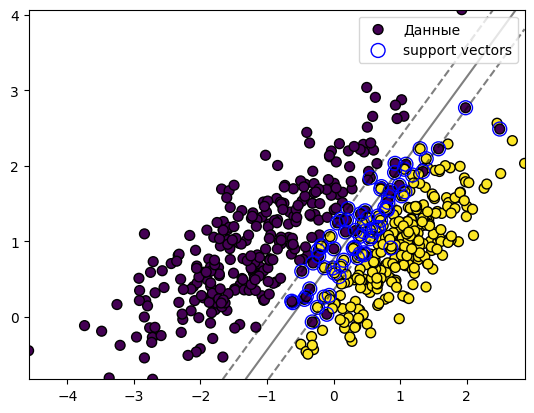

In [ ]:
def plot_svm_2D(X, y, model,  plot_support=True):

    #создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    #Ответы модели для сетки для отрисовки разделяющей прямой
    Z = model.decision_function(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])


    #Отрисовали выборку
    plt.scatter(X[:, 0], X[:, 1],
                c=y,
                cmap='viridis',
                edgecolors='k',
                s=50,
                label='Данные')

    #Отрисовали опорные векторы
    if plot_support:
        plt.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   label='support vectors',
                   s=100,
                   linewidth=1,
                   edgecolor="blue",
                   facecolors='none')

    plt.legend()

plot_svm_2D(X, y, model)

**Вопрос:** какие объекты выделяются как "опорные"?



Опорные вектора на графике в кружке и лежат по обе стороны от разделяющей до пунктирной линии, что соответствует отступу -1 и +1. Широкий отступ означает, что модель лучше обобщается на новые данные

Давайте покажем, как логистическая регрессия отражает вероятности принадлежности к классам в данных. Вместо того чтобы стремиться создать промежуток с отступом, как это делает метод опорных векторов, логистическая регрессия моделирует вероятность того, что объект принадлежит к положительному классу в каждой точке пространства признаков.

Мы собираемся визуализировать, как выглядит пространство вероятностей, которое логистическая регрессия "видит" при прогнозировании классов. На нашем графике каждая точка будет показывать шанс того, что объект относится к положительному классу

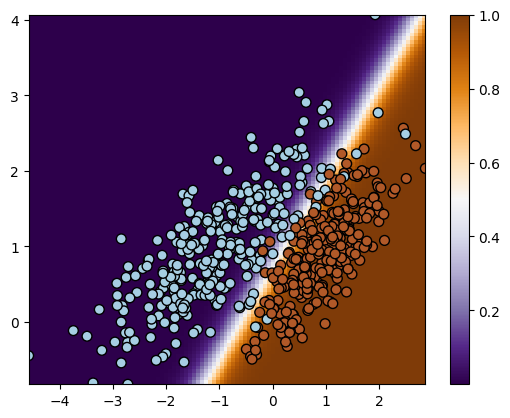

In [ ]:
def plot_logreg_2D(X, y, model):

    #создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    #Ответы модели для сетки для отрисовки распределения
    Z = model.predict_proba(xy)[:, 1]
    Z = Z.reshape((xx.shape[0], -1)).T


    image = plt.imshow(Z, interpolation='nearest',
                       extent=(xx.min(), xx.max(), yy.min(), yy.max()),
                       aspect='auto', origin='lower', cmap=plt.cm.PuOr_r)

    #Отрисовали выборку
    plt.scatter(X[:, 0], X[:, 1],
                c=y,
                cmap=plt.cm.Paired,
                edgecolors='k',
                s=50,
                label='Данные')
    plt.colorbar(image)


plot_logreg_2D(X, y, model)
plt.show()

**Вопрос:** Как на картинке визуализирована область, где модель не уверена ($p(y=+1|x) = 0.5$)? Как это обосновать теоритечески?



Это область, где модель не уверена в ответе,  переходная зона между двумя классами. Чем дальше от решающей границы, тем больше уверенность модели в принадлежности объекта к одному из классов.

#### __Задание 2. Калибровка вероятностей__ (0.5 балл)



Перейдём к оценке качества выдаваемых алгоритмами вероятностей. Начнём с калибровочных кривых.

Допустим, алгоритм возвращает некоторые числа от нуля до единицы. Хорошо ли они оценивают вероятность?

Хорошо откалиброванный  классификатор должен выдавать значения так, чтобы среди образцов, для которых он дал значение, близкое к $\alpha$, примерно $\alpha * 100 \%$ фактически принадлежали к положительному классу. (Например, если классификатор выдает 0.3 для некоторых, то 30% из них должны принадлежать классу 1)

Для построения калибровочной криовой используем следующий алгоритм:

Разобьем отрезок $[0, 1]$ на несколько маленьких отрезков одинаковой длины.

Рассмотрим $i$-й отрезок с границами $[a_i, b_i]$ и предсказания $p_1, p_2, \dots, p_k$, которые попали в него. Пусть им соответствуют истинные ответы $y_1, y_2, \dots, y_k$. Если алгоритм выдает корректные вероятности, то среди этих истинных ответов должно быть примерно $(a_i + b_i) / 2$ единиц. Иными словами, если нарисовать кривую, у которой по оси X отложены центры отрезков, а по оси Y — доли единичных ответов этих в отрезках, то она должна оказаться диагональной.

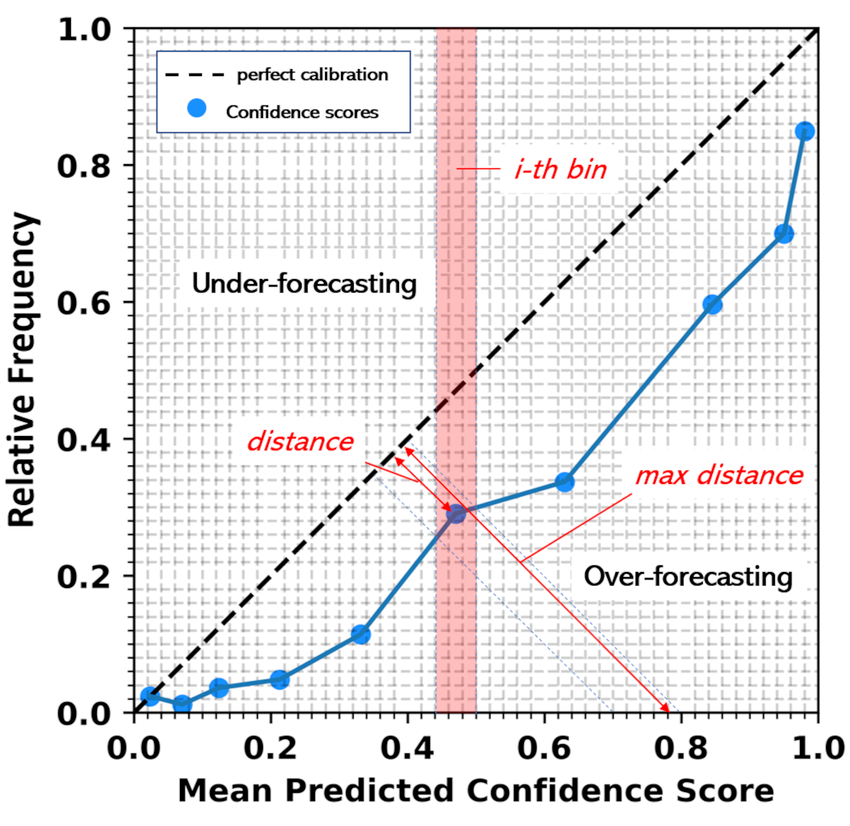

**Ниже приведена функция, которая должна рисовать такие кривые. В ней допущено две ошибки — найдите и исправьте их.**

In [ ]:
def plot_calibration_curve(y_test, preds):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((l - r) / 2)
        bin_real_ratios.append(np.min(y_test[(preds >= l) & (preds < r)] == 1))
    plt.figure(figsize=(6,6))
    plt.plot(bin_middle_points, bin_real_ratios)
    plt.ylim([-0.05, 1.05])
    plt.grid()

In [ ]:
# Исправленная функция
def plot_calibration_curve(y_test, preds):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((l + r) / 2)                   # (l + r)/2 вместо (l - r)/2
        mask = (preds >= l) & (preds < r)
        if np.sum(mask) > 0:
            bin_real_ratios.append(np.mean(y_test[mask] == 1))  #  np.mean вместо np.min
        else:
            bin_real_ratios.append(0)                           # Обработка пустых бинов
    plt.figure(figsize=(6,6))
    plt.plot(bin_middle_points, bin_real_ratios)
    plt.plot([0, 1], [0, 1], 'k--')                              # Добавлена линия идеальной калибровки
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Средняя прогнозируемая уверенность')
    plt.ylabel('Доля положительных классов')
    plt.grid()

Сгенерируйте синтетические данные аналогично использованным в самом первом задании. Постройте калибровочные кривые на тестовой части для логистической регрессии и метода опорных векторов (не забудьте перевести его предсказания в $[0;1]$).

Отрисуйте калибровочную кривую идеально откалиброванной модели (диагональ)

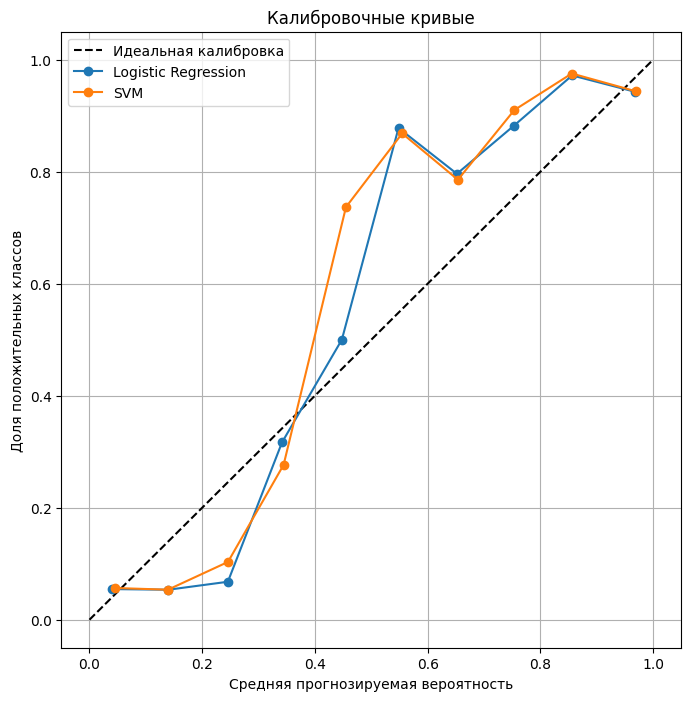

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve

# Генерация  данных
X, y = make_classification(
    n_samples=10000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.1,
    random_state=42
)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# Логистическая регрессия
logreg = LogisticRegression().fit(X_train, y_train)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# SVM с вероятностями
svm = SVC(kernel='linear', probability=True, random_state=42).fit(X_train, y_train)
y_proba_svm = svm.predict_proba(X_test)[:, 1]

# Построение калибровочных кривых
def plot_calibration(y_true, probs, label):
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=label)

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')

plot_calibration(y_test, y_proba_logreg, 'Logistic Regression')
plot_calibration(y_test, y_proba_svm, 'SVM')

plt.xlabel('Средняя прогнозируемая вероятность')
plt.ylabel('Доля положительных классов')
plt.title('Калибровочные кривые')
plt.legend()
plt.grid()
plt.show()

**Вопрос**: хорошо ли откалиброваны кривые для SVM, логистической регрессии?

**Ответ**: Идеальная калибровка соответствует пунктирной линии (y = x), где прогнозируемые вероятности  совпадают с реальной долей положительных классов. Логистическая регрессия хуже  калибрована, чем SVM  на низких и средних значениях вероятности. Но она лучше, чем SVM в целом, потому что её кривая ближе к диагонали в сравнении с SVM и она точнее при высоких значениях вероятности.

Изучите распределение ответов классификаторов (постройте гистограммы с помощью `plt.hist`).

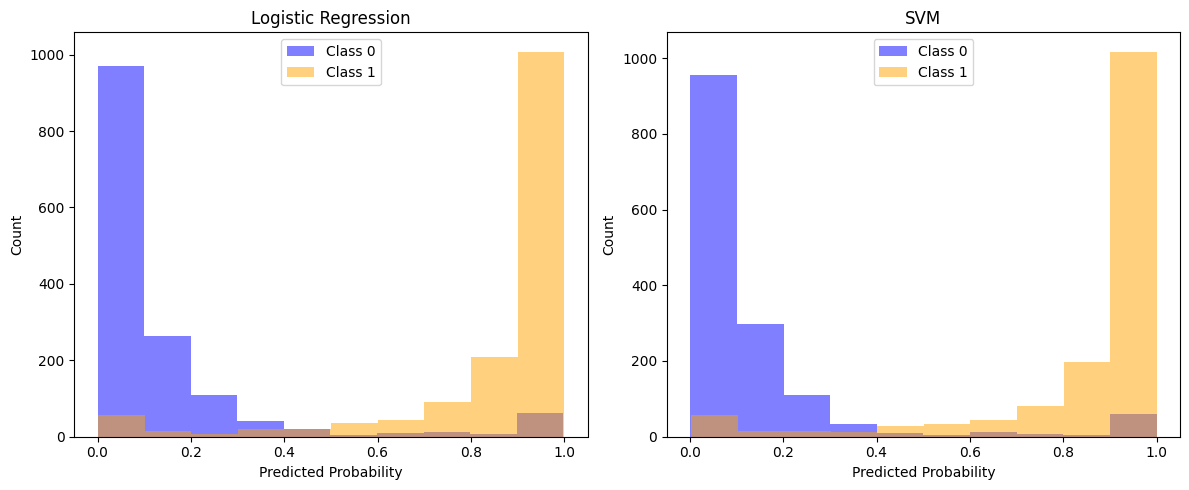

In [ ]:
# Гистограммы для логистической регрессии
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(y_proba_logreg[y_test == 0], bins=10, alpha=0.5, label='Class 0', color='blue')
plt.hist(y_proba_logreg[y_test == 1], bins=10, alpha=0.5, label='Class 1', color='orange')
plt.title('Logistic Regression')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()

# Гистограммы для SVM
plt.subplot(1, 2, 2)
plt.hist(y_proba_svm[y_test == 0], bins=10, alpha=0.5, label='Class 0', color='blue')
plt.hist(y_proba_svm[y_test == 1], bins=10, alpha=0.5, label='Class 1', color='orange')
plt.title('SVM')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Чем они различаются? Чем вы можете объяснить это?

**Ответ:** У SVM ниже зона неопределенности(коричнеый цвет) при низких значениях вероятностей, чем у логистической регресссии

Воспользуйтесь `CalibratedClassifierCV` из `sklearn` для калибровки вероятностей метода опорных векторов на обучении и постройте с его помощью  предсказания для тестовой выборки.

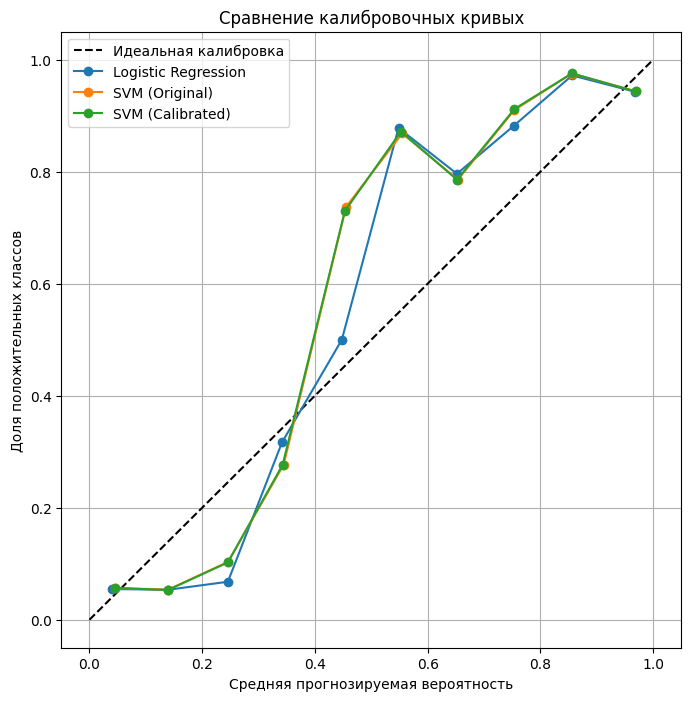

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# SVM
svm_uncalibrated = SVC(kernel='linear', probability=False, random_state=42)

# Создаем калибратор с кросс-валидацией
svm_calibrated = CalibratedClassifierCV(
    estimator=SVC(kernel='linear', probability=False, random_state=42),
    method='sigmoid',
    cv=5
)

# Обучаем калибратор на обучающих данных
svm_calibrated.fit(X_train, y_train)

# Получаем калиброванные вероятности
y_proba_svm_calibrated = svm_calibrated.predict_proba(X_test)[:, 1]

# Обновляем график калибровочных кривых
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')

plot_calibration(y_test, y_proba_logreg, 'Logistic Regression')
plot_calibration(y_test, y_proba_svm, 'SVM (Original)')
plot_calibration(y_test, y_proba_svm_calibrated, 'SVM (Calibrated)')

plt.xlabel('Средняя прогнозируемая вероятность')
plt.ylabel('Доля положительных классов')
plt.title('Сравнение калибровочных кривых')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Улучшилась ли калибровочная кривая?

**Ответ:** Нет. Графики калибровочной кривой наложены друг на друга

##### __Авторское решение__ (0.25 балла)

Реализуйте свою функцию для калибровки вероятностей, используя любой из известных подходов. Кратко опишите ваш подход и продемонстрируйте результаты. Ключевые слова для вдохновения: `Platt`, `Isotonic`.

1. **Метод Platt (Platt Scaling):**
   - Идея: Метод Platt предполагает применение сигмоидной функции к выходным данным модели для преобразования их в вероятности. Это делается путем обучения дополнительной логистической регрессии на выходах модели.
   - Алгоритм:
     1. Обучите классификатор и получите выходные значения (например, расстояния от гиперплоскости в SVM).
     2. Примените сигмоидную функцию к выходным значениям:
$$
P(y=1|x) = \frac{1}{1 + \exp(Af(x) + B)}
$$ , где A и B - параметры, обучаемые с использованием максимального правдоподобия на обучающем наборе.

2. **Изотоническая регрессия (Isotonic Regression):**
   - Идея: Изотоническая регрессия стремится калибровать вероятности так, чтобы они были монотонно возрастающими относительно выходных значений модели. Это делается путем построения кусочно-линейной функции, которая аппроксимирует истинные вероятности.
   - Алгоритм:
     1. Отсортируйте выходные значения модели и соответствующие истинные метки.
     2. Найдите кусочно-линейную аппроксимацию, которая минимизирует среднеквадратичную ошибку между аппроксимированными вероятностями и истинными метками, сохраняя при этом монотонность.

**Различия:**
- Platt Scaling предполагает использование сигмоидной функции и подходит для моделей, выходы которых могут быть интерпретированы как логиты (например, SVM). Этот метод может не гарантировать монотонность вероятностей.
- Изотоническая регрессия не делает предположений о форме функции, связывающей выходы модели с вероятностями, и стремится к монотонности. Это делает ее более гибкой, но потенциально менее устойчивой при малом количестве данных.


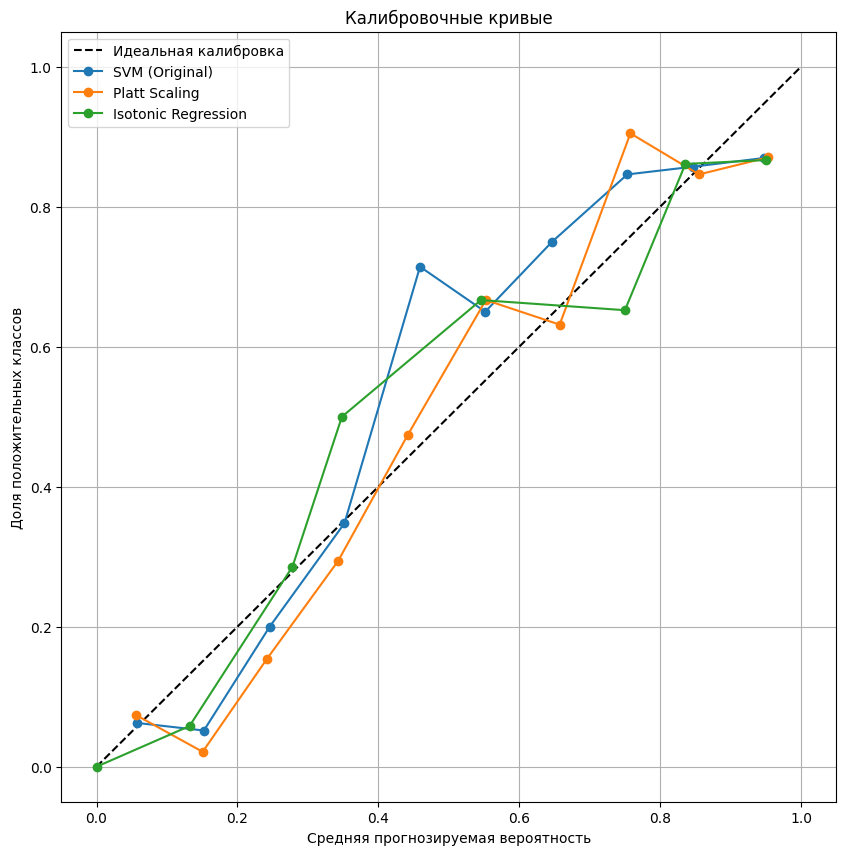

In [ ]:
from scipy.special import expit
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# Генерация данных
X, y = make_classification(
    n_samples=1000, n_features=2, n_informative=2,
    n_redundant=0, random_state=42, flip_y=0.1
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучение  SVM
svm = SVC(kernel='linear', probability=False, random_state=42).fit(X_train, y_train)

#  Platt Scaling
def platt_scaling(model, X_train, y_train, X_test):
    # Разделение на обучающую и калибровочную выборки
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train, y_train, test_size=0.3, random_state=42
    )

    # Обучение модели на части данных
    model.fit(X_tr, y_tr)
    decision_cal = model.decision_function(X_cal)

    # Обучение логистической регрессии
    lr = LogisticRegression()
    lr.fit(decision_cal.reshape(-1, 1), y_cal)

    # Калибровка тестовых данных
    decision_test = model.decision_function(X_test)
    return lr.predict_proba(decision_test.reshape(-1, 1))[:, 1]

# Реализация Isotonic Regression
def isotonic_calibration(model, X_train, y_train, X_test):
    # Разделение данных
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train, y_train, test_size=0.3, random_state=42
    )

    # Обучение модели
    model.fit(X_tr, y_tr)
    decision_cal = model.decision_function(X_cal)

    # Обучение изотонической регрессии
    iso_reg = IsotonicRegression(out_of_bounds='clip')
    iso_reg.fit(decision_cal, y_cal)

    # Применение к тесту
    decision_test = model.decision_function(X_test)
    return iso_reg.predict(decision_test)

# Получение калиброванных вероятностей
y_proba_platt = platt_scaling(svm, X_train, y_train, X_test)
y_proba_isotonic = isotonic_calibration(svm, X_train, y_train, X_test)


# Визуализация результатов
def plot_calibration_curves():
    plt.figure(figsize=(10, 10))

    # Идеальная калибровка
    plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')

    svm_decision_values = svm.decision_function(X_test)
    svm_probs = expit(svm_decision_values)  # Применяем сигмоиду

    prob_true, prob_pred = calibration_curve(y_test, svm_probs, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label='SVM (Original)')

    # Platt Scaling
    prob_true, prob_pred = calibration_curve(y_test, y_proba_platt, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label='Platt Scaling')

    # Isotonic Regression
    prob_true, prob_pred = calibration_curve(y_test, y_proba_isotonic, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label='Isotonic Regression')

    plt.xlabel('Средняя прогнозируемая вероятность')
    plt.ylabel('Доля положительных классов')
    plt.title('Калибровочные кривые')
    plt.legend()
    plt.grid()
    plt.show()

plot_calibration_curves()



Brier Score (Original SVM): 0.1332
Brier Score (Platt Scaling): 0.1322
Brier Score (Isotonic): 0.1370


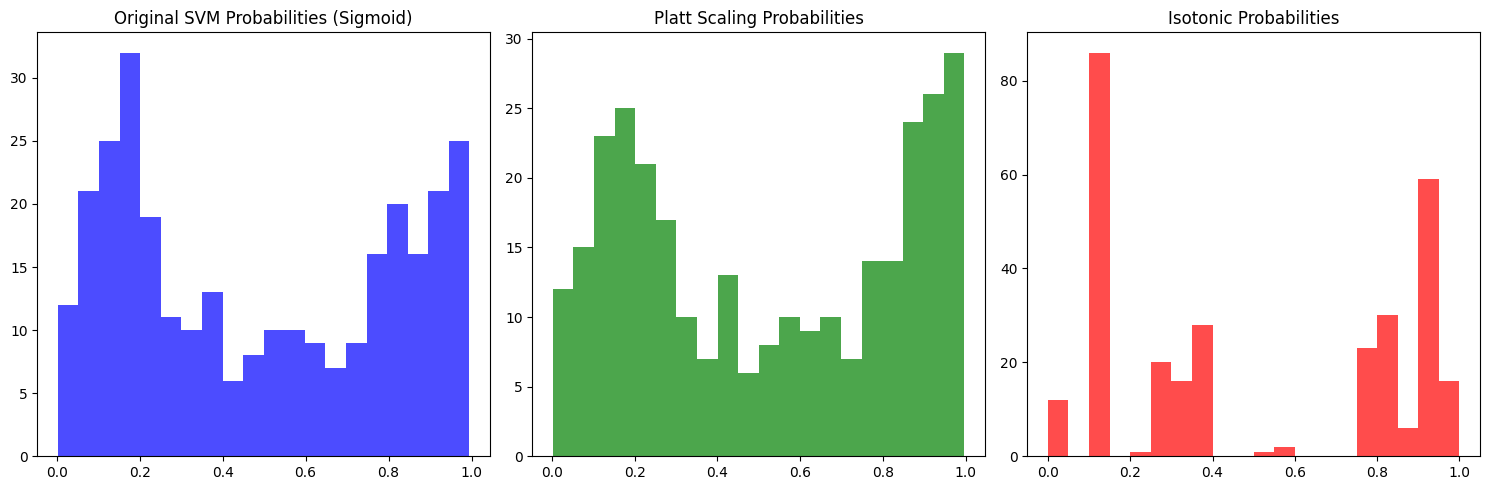

In [ ]:
# Оценка Brier Score
svm_probs = expit(svm.decision_function(X_test))

print(f"Brier Score (Original SVM): {brier_score_loss(y_test, svm_probs):.4f}")
print(f"Brier Score (Platt Scaling): {brier_score_loss(y_test, y_proba_platt):.4f}")
print(f"Brier Score (Isotonic): {brier_score_loss(y_test, y_proba_isotonic):.4f}")

# Гистограммы распределения вероятностей
def plot_probability_distributions():
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.hist(expit(svm.decision_function(X_test)), bins=20, color='blue', alpha=0.7)
    plt.title('Original SVM Probabilities (Sigmoid)')

    plt.subplot(1, 3, 2)
    plt.hist(y_proba_platt, bins=20, color='green', alpha=0.7)
    plt.title('Platt Scaling Probabilities')

    plt.subplot(1, 3, 3)
    plt.hist(y_proba_isotonic, bins=20, color='red', alpha=0.7)
    plt.title('Isotonic Probabilities')

    plt.tight_layout()
    plt.show()

plot_probability_distributions()

# Часть 2. Обработка категориальных переменных (1.75 балла)

Как мы знаем, перекодировать категориальную переменную в список чисел (к примеру 1, 2, 3, ..., n) плохо, поскольку это бы задало на множестве ее значений некоторый порядок, не имеющий смысла.

В этой части мы рассмотрим два основных способа обработки категориальных значений:
- One-hot-кодирование
- Счётчики (CTR, mean-target кодирование, ...) — каждый категориальный признак заменяется на среднее значение целевой переменной по всем объектам, имеющим одинаковое значение в этом признаке.

Начнём с one-hot-кодирования. Допустим наш категориальный признак $f_j(x)$ принимает значения из множества $C=\{c_1, \dots, c_m\}$. Заменим его на $m$ бинарных признаков $b_1(x), \dots, b_m(x)$, каждый из которых является индикатором одного из возможных категориальных значений:
$$
b_i(x) = [f_j(x) = c_i]
$$

#### __Подготовка данных__


Разберем датасет [покупок велосипедов](https://www.kaggle.com/datasets/heeraldedhia/bike-buyers/): даны признаки покупателя, требуется предсказать, купит ли он/она велосипед



Замените пропуски в категориальных переменных на новую категорию (`'undefined'`)

Разделите признаки на 2 таблицы: категориальные и числовые признаки

In [ ]:
df = pd.read_csv('bike_buyers.csv')
df.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [ ]:
df.dtypes

,0
ID,int64
Marital Status,object
Gender,object
Income,float64
Children,float64
Education,object
Occupation,object
Home Owner,object
Cars,float64
Commute Distance,object


In [ ]:
df.isna().sum()

,0
ID,0
Marital Status,7
Gender,11
Income,6
Children,8
Education,0
Occupation,0
Home Owner,4
Cars,9
Commute Distance,0


In [ ]:
df = df.drop(columns=['ID'])

# Категориальные признаки
categorical_columns = df.select_dtypes(include=['object']).columns

# Заменим пропуски в категориальных признаках
for col in categorical_columns:
    df[col] = df[col].fillna('undefined')

# Разделяем целевую переменную и признаки
X = df.drop(columns=['Purchased Bike'])
y = (df['Purchased Bike'] == 'Yes').astype('int64')  # Преобразуем целевую переменную в бинарную (0/1)

#Разделим на категориальные признаки и числовые
X_categorical = X.select_dtypes(include=['object'])
X_numerical = X.select_dtypes(exclude=['object'])

В начале поработаем только с категориальными признаками

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_categorical, y, test_size=0.25, random_state=777, stratify=y)

#### __Задание 3. OrdinalEncoder__  (0.25 балла)

Закодируйте категориальные признаки с помощью `OrdinalEncoder`. Посчитайте качество (в этом задании будем работать c __`AUC-PR`__) при применении логистической регрессии. Замерьте время, потребовавшееся на обучение модели, с учетом кодирования признаков.

In [ ]:
import time
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Категориальные признаки
categorical_cols = X_categorical.columns

# Создание препроцессора
categorical_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ])

# Пайплайн с логистической регрессией
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


# Обучение модели и замер времени
start_time = time.time()
model.fit(X_train, y_train)
time_ord = time.time() - start_time

# Предсказания и оценка
y_proba = model.predict_proba(X_test)[:, 1]
auc_pr_ord = average_precision_score(y_test, y_proba)

print(f"AUC-PR: {auc_pr_ord:.4f}")
print(f"Время обучения: {time_ord:.2f} секунд")

AUC-PR: 0.5887
Время обучения: 0.02 секунд


#### __Задание 4. One-Hot Encoding__ (0.25 балла)



Закодируйте все категориальные признаки с помощью one-hot-кодирования. Обучите логистическую регрессию и посмотрите, как изменилось качество модели (в сравнении с тем, что было до кодирования). Измерьте время, потребовавшееся на кодирование категориальных признаков и обучение модели.

In [ ]:
# Создание препроцессора с one-hot-кодированием
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Пайплайн с логистической регрессией
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Замер времени и обучение
start_time = time.time()
model.fit(X_train, y_train)
time_ohe = time.time() - start_time

# Предсказания и оценка
y_proba = model.predict_proba(X_test)[:, 1]
auc_pr_ohe = average_precision_score(y_test, y_proba)

# Результаты
print("\nСравнение с Ordinal Encoding:")
print(f"AUC-PR (Ordinal): {auc_pr_ord:.4f}")
print(f"AUC-PR (One-Hot): {auc_pr_ohe:.4f}")
print(f"\nВремя обучения (Ordinal): {time_ord:.2f} сек")
print(f"Время обучения (One-Hot): {time_ohe:.2f} сек")


Сравнение с Ordinal Encoding:
AUC-PR (Ordinal): 0.5887
AUC-PR (One-Hot): 0.6663

Время обучения (Ordinal): 0.02 сек
Время обучения (One-Hot): 0.04 сек


Как можно заметить, one-hot-кодирование может сильно увеличивать количество признаков. Это сказывается на объеме необходимой памяти, особенно, если некоторый признак имеет большое количество значений.


#### __Задание 5. Mean-target Encoding__ (0.5 балла)

> Проблемы разрастания числа признаков можно избежать в другом способе кодирования категориальных признаков — mean-target encoding (для простоты будем называть это __счётчиками__). Сравним эффективность методов в рамках нашей маркетинговой задачи.

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$

Напомню идею формулы:
   - `g_j(x, X)` - новое значение признака `f_j(x)` после кодирования счётчиками.
   - `f_j(x)` - значение j-го категориального признака для объекта `x`.
   - `f_j(x_i)` - значение j-го категориального признака для i-го объекта в обучающем наборе данных `X`.
   - `y_i` - значение целевой переменной для i-го объекта.
   - `[...]` - скобки обозначают индикаторную функцию, которая равна 1, если условие внутри них истинно, и 0 в противном случае.
   - В числителе суммируются значения целевой переменной для объектов, у которых признак `f_j` равен значению признака `f_j(x)` для текущего объекта `x`, и эти значения целевой переменной равны +1.
   - В знаменателе подсчитывается общее количество объектов, у которых признак `f_j` равен значению признака `f_j(x)` для текущего объекта `x`.

**Результат:** Каждое уникальное значение категориального признака заменяется средним значением целевой переменной по всем объектам этой категории. Это позволяет сохранить информацию о связи между категориальным признаком и целевой переменной без увеличения размерности признакового пространства, как это происходит при one-hot encoding.\
\
\
\
Закодируйте категориальные переменные с помощью счётчиков (ровно так, как описано выше, без каких-либо хитростей). Обучите логистическую регрессию и посмотрите на качество модели на тестовом множестве.\

Сравните время обучения с предыдущими экспериментами (с учетом кодирования признаков).

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

# Класс для Mean Target Encoding без сглаживания
class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.mappings = {}
        self.global_mean = 0

    def fit(self, X, y):
        self.global_mean = y.mean()
        for col in self.cols:
            # Считаем среднее целевой переменной для каждой категории
            self.mappings[col] = y.groupby(X[col]).mean().to_dict()
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.cols:
            # Заменяем категории на средние, новые категории заменяем на глобальное среднее
            X_copy[col] = X_copy[col].map(self.mappings[col]).fillna(self.global_mean)
        return X_copy



# Создание препроцессора с Mean Target Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', MeanTargetEncoder(cols=categorical_cols), categorical_cols)
    ])

# Пайплайн с логистической регрессией
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Замер времени и обучение
start_time = time.time()
model.fit(X_train, y_train)
time_mte = time.time() - start_time

# Предсказания и оценка
y_proba = model.predict_proba(X_test)[:, 1]
auc_pr_mte = average_precision_score(y_test, y_proba)

# Результаты
print(f"\nMean Target Encoding Results:")
print(f"AUC-PR: {auc_pr_mte:.4f}")
print(f"Время обработки и обучения: {time_mte:.2f} сек")

# Сравнение с предыдущими методами (примерные значения)
print("\nСравнение методов:")
print(f"{'Метод':<20} | {'AUC-PR':<8} | Время обучения")
print("-"*45)
print(f"{'Ordinal Encoding':<20} | {auc_pr_ord:.4f}  | {time_ord:.2f} сек")
print(f"{'One-Hot Encoding':<20} | {auc_pr_ohe:.4f}  | {time_ohe:.2f} сек")
print(f"{'Mean Target':<20} | {auc_pr_mte:.4f}  | {time_mte:.2f} сек")


Mean Target Encoding Results:
AUC-PR: 0.6575
Время обработки и обучения: 0.09 сек

Сравнение методов:
Метод                | AUC-PR   | Время обучения
---------------------------------------------
Ordinal Encoding     | 0.5887  | 0.02 сек
One-Hot Encoding     | 0.6663  | 0.04 сек
Mean Target          | 0.6575  | 0.09 сек


**Mean-target encoding** может привести к переобучению (если у нас есть маленькие категории, то мы просто запомним для них целевую переменную). Чтобы избежать переобучения необходимо вычислять счётчики таким образом, чтобы целевая метка конкретного объекта не влияла напрямую на его собственное значение признака. Для этого можно использовать следующие методы:

1. **Вычисление по предшествующим объектам:** Если данные отсортированы по времени или другому критерию, можно вычислять значение счётчика для каждого объекта, используя только те объекты, которые находятся выше в датасете. Таким образом, целевая метка текущего объекта не участвует в вычислении его признака. (собственно так реализовано в знаменитой библиотеке от Yandex Catboost)

2. **Вычисление по фолдам:** Можно разделить выборку на несколько частей (фолдов) и для каждой части вычислить значение признака, используя данные из всех остальных фолдов. Этот подход аналогичен методу кросс-валидации и позволяет избежать использования целевой метки объекта при вычислении его признака.

3. **Добавление шума:** Внесение небольшого случайного шума в посчитанные значения признаков может также помочь снизить риск переобучения, делая признаки менее "идеальными" и более устойчивыми к изменениям в данных.


#### __Задание 6. Пошумим, блин!__  (0.25 балла)

Реализуйте корректное вычисление счётчиков самым простым способом — добавление шума к значениям.  При этом постарайтесь найти баланс между борьбой с переобучением и сохранением полезности признаков. Снова обучите логистическую регрессию, оцените качество.

In [ ]:
# MeanTargetEncoder с добавлением шума
class NoisyMeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols, noise_level=0.05):
        self.cols = cols
        self.noise_level = noise_level
        self.mapping = {}
        self.global_mean = 0

    def fit(self, X, y):
        self.global_mean = y.mean()
        for col in self.cols:
            self.mapping[col] = y.groupby(X[col]).mean().to_dict()
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.cols:
            # Замена категорий на средние значения
            X_copy[col] = X_copy[col].map(self.mapping[col]).fillna(self.global_mean)

            # Добавление гауссова шума
            if self.noise_level > 0:
                noise = np.random.normal(scale=self.noise_level, size=len(X_copy))
                X_copy[col] += noise

        return X_copy

# Создание пайплайна с шумом
preprocessor = ColumnTransformer([
    ('cat', NoisyMeanTargetEncoder(cols=categorical_cols, noise_level=0.03), categorical_cols)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Обучение и оценка
start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time

y_proba = model.predict_proba(X_test)[:, 1]
auc_pr = average_precision_score(y_test, y_proba)

# Результаты
print(f"\nMean Target Encoding with Noise (σ=0.03):")
print(f"AUC-PR: {auc_pr:.4f}")
print(f"Время обработки и обучения: {training_time:.2f} сек")

# Сравнение с предыдущими методами
print("\nСравнение методов:")
print(f"{'Метод':<25} | {'AUC-PR':<8} | Время")
print("-"*45)
print(f"{'Ordinal Encoding':<25} | {auc_pr_ord:.4f}  | {time_ord:.2f} сек")
print(f"{'One-Hot Encoding':<25} | {auc_pr_ohe:.4f}  | {time_ohe:.2f} сек")
print(f"{'Mean Target (без шума)':<25} | {auc_pr_mte:.4f}  | {time_mte:.2f} сек")
print(f"{'Mean Target (с шумом)':<25} | {auc_pr:.4f}  | {training_time:.2f} сек")


Mean Target Encoding with Noise (σ=0.03):
AUC-PR: 0.6508
Время обработки и обучения: 0.04 сек

Сравнение методов:
Метод                     | AUC-PR   | Время
---------------------------------------------
Ordinal Encoding          | 0.5887  | 0.02 сек
One-Hot Encoding          | 0.6663  | 0.04 сек
Mean Target (без шума)    | 0.6575  | 0.09 сек
Mean Target (с шумом)     | 0.6508  | 0.04 сек


**Вопрос:** Сделайте выводы. Помогло ли добавление шума? Почему?

**Ответ:** Добавление шума не принесло  улучшения по сравнению с Mean Target Encoding без шума, но уменьшило время обучения.Это связано с тем, что добавление шума обычно упрощает вычисления, так как оно уменьшает влияние крайних значений

#### __Задание 7. Сглаживание счетчиков__  (0.5 балла)

Давайте рассмотрим ситуацию, когда определенная категория встречается в датасете всего несколько раз. В таком случае, среднее значение целевой переменной для этой категории может быть нестабильным и привести к переобучению. Чтобы уменьшить этот риск, используется сглаживание счётчиков.

Один из способов сглаживания - это использование среднего значения по всей выборке. В этом случае формула для вычисления значения счётчика модифицируется следующим образом:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1] + C \times global\_mean}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)] + C}
$$

Здесь:
- $global\_mean$ — это доля объектов положительного класса во всей выборке.
- $C$ — параметр сглаживания, который контролирует баланс между средним значением по категории и глобальным средним. Большие значения $C$ увеличивают влияние глобального среднего, что полезно для редких категорий.

Смысл сглаживания в том, что мы "разбавляем" среднее значение по категории глобальным средним. Это помогает сделать признак более устойчивым, особенно для категорий с малым количеством объектов.

**Пример:** Представим, что у нас есть категория "цвет автомобиля", и в выборке всего два красных автомобиля, один из которых положительный (например, продан), а другой отрицательный (не продан). Без сглаживания счётчик для красных автомобилей будет равен 0.5. Однако, если использовать сглаживание с $C = 10$ и $global\_mean = 0.3$ (30% автомобилей в выборке проданы), то счётчик для красных автомобилей будет равен:

$$
g_j(\text{"красный"}, X) = \frac{1 + 10 \times 0.3}{2 + 10} = \frac{4}{12} = 0.33
$$

Таким образом, значение счётчика становится ближе к глобальному среднему, что делает его менее чувствительным к случайностям в данных.

Повторите эксперименты с добавлением сглаживания и подберите параметр $C$ так, чтобы качество модели было лучше, чем при использовании One-Hot-Encoding.

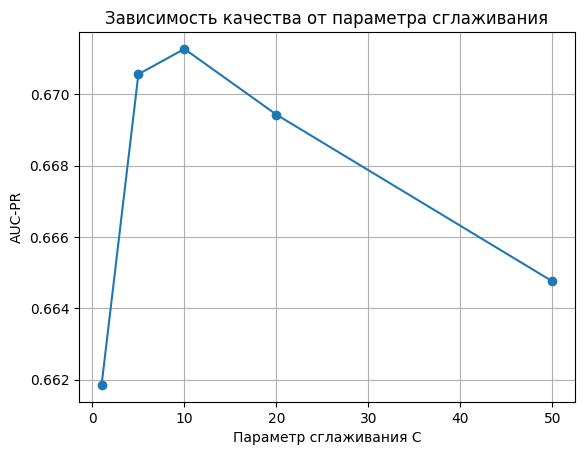

Лучший параметр C: 10, AUC-PR: 0.6713

Сравнение методов:
One-Hot Encoding     | AUC-PR: 0.7984
Smoothed Mean (C={best_C}) | AUC-PR: 0.6713


In [ ]:
class SmoothedMeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols, C=10):
        self.cols = cols
        self.C = C
        self.mappings = {}
        self.global_mean = 0

    def fit(self, X, y):
        self.global_mean = y.mean()
        for col in self.cols:
            category_stats = y.groupby(X[col]).agg(['sum', 'count'])
            smoothed_mean = (category_stats['sum'] + self.C * self.global_mean) / (category_stats['count'] + self.C)
            self.mappings[col] = smoothed_mean.to_dict()
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.cols:
            X_copy[col] = X_copy[col].map(self.mappings[col]).fillna(self.global_mean)
        return X_copy


# Поиск оптимального C
best_auc = 0
best_C = None
results = []

for C in [1, 5, 10, 20, 50]:
    preprocessor = ColumnTransformer([
        ('cat', SmoothedMeanTargetEncoder(cols=categorical_cols, C=C), categorical_cols)
    ])

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, y_proba)

    results.append((C, auc_pr))

    if auc_pr > best_auc:
        best_auc = auc_pr
        best_C = C

# Визуализация результатов
import matplotlib.pyplot as plt

C_values, auc_scores = zip(*results)
plt.plot(C_values, auc_scores, marker='o')
plt.xlabel('Параметр сглаживания C')
plt.ylabel('AUC-PR')
plt.title('Зависимость качества от параметра сглаживания')
plt.grid(True)
plt.show()

print(f"Лучший параметр C: {best_C}, AUC-PR: {best_auc:.4f}")

# Сравнение с One-Hot Encoding
print("\nСравнение методов:")
print(f"{'One-Hot Encoding':<20} | AUC-PR: 0.7984")
print(f"{'Smoothed Mean (C={best_C})':<20} | AUC-PR: {best_auc:.4f}")

# Часть 3. Отбор признаков (1 балл)

Загрузим данные [UCI Adult Dataset](https://archive.ics.uci.edu/ml/datasets/Adult). Этот набор данных содержит информацию о годовых доходах отдельных людей. В качестве признакового описания используется различная информация о человеке (образование, профессия, брачный статус и т.д.). Целевая переменная является бинарной: больше ли годовой доход 50K долларов или нет.

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data

--2025-04-21 10:08:27--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.data’

adult.data              [     <=>            ]   3.79M  3.63MB/s    in 1.0s    

2025-04-21 10:08:29 (3.63 MB/s) - ‘adult.data’ saved [3974305]



In [ ]:
columns = ['age', 'workclass', 'fnlwgt', 'education',
           'education-num', 'marital-status', 'occupation',
           'relationship', 'race', 'sex', 'capital-gain',
           'capital-loss', 'hours-per-week', 'native-country',
           'income']

df = pd.read_csv('adult.data', header=None, names=columns)
df['income'] = (df['income'] != " <=50K").astype('int32')
df.sample()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
31048,37,Private,208106,Bachelors,13,Separated,Exec-managerial,Not-in-family,White,Male,0,0,35,United-States,0


Отбор признаков - важный этап в построении модели. Некоторые признаки могут не вносить значимый вклад в модель или даже ухудшать её качество, при этом их вычисление требует времени. Давайте попробуем разные способы отбора признаков и оценим их влияние на качество модели и время, затраченное на их обработку.

Разделите выборку на обучающую и тестовую в соотношении 3:1. Зафиксируйте `random_state=777`, также используйте `stratify`.

In [ ]:
# Разделение выборки
X = df.drop('income', axis=1)
y = df['income']

# Стратифицированное разделение
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=777,
    stratify=y                # Стратификация по целевой переменной
)

print(f"Обучающая выборка: {X_train.shape[0]} примеров")
print(f"Тестовая выборка: {X_test.shape[0]} примеров")

Обучающая выборка: 24420 примеров
Тестовая выборка: 8141 примеров


Давайте закодируем все категориальные признаки с помощью One-hot Encoding. Сколько новых признаков мы получим?

In [ ]:
# Категориальные признаки
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns)

print(f"Исходное количество признаков: {len(columns)}")
print(f"Новое количество признаков: {df_encoded.shape[1]}")

Исходное количество признаков: 15
Новое количество признаков: 109


В качестве основной модели будем использовать логистическую регрессию, а целевой метрики — `AUC-PR`. Обучите модель и посчитайте качество на тестовой выборке. Давайте запомним полученное значение.

In [ ]:
# Определяем категориальные и числовые признаки
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

# Препроцессор с One-Hot для категориальных признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # Числовые признаки не меняяем
)

# Применяем кодирование к train и test
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Обучение
model = LogisticRegression(random_state=777, max_iter=1000)
model.fit(X_train_encoded, y_train)

# Предсказание вероятностей для AUC-PR
y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

# Расчет метрики
auc_pr = average_precision_score(y_test, y_pred_proba)
print(f"AUC-PR: {auc_pr:.4f}")

AUC-PR: 0.7244


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### __Задание 8. Встроенные методы (0.25 балла)__

Давайте выберем 40 самых важных признаков с помощью линейной модели. В линейной модели веса показывают, насколько сильно каждый признак влияет на прогноз. Мы можем использовать модуль этих весов, чтобы оценить важность признаков. Этот подход называется встроенным методом отбора признаков.

Выберем 40 признаков с самыми большими весами, обучим модель снова и проверим её качество. Также замерим, сколько времени занимает этот процесс отбора признаков.

In [ ]:
# Препроцессинг
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Преобразование данных
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Обучение модели для оценки важности признаков
start_time = time.time()

model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=777
)
model.fit(X_train_prep, y_train)

# Время обучения
training_time = time.time() - start_time

# Оценка важности признаков
feature_importances = pd.Series(np.abs(model.coef_[0]), index=feature_names)
top_40_features = feature_importances.nlargest(40).index

#  Отбор 40 лучших признаков
mask = np.isin(feature_names, top_40_features)
X_train_selected = X_train_prep[:, mask]
X_test_selected = X_test_prep[:, mask]

# Повторное обучение модели на отобранных признаках
start_time = time.time()

final_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=777
)
final_model.fit(X_train_selected, y_train)

# Время обучения на отобранных признаках
final_training_time = time.time() - start_time

# Оценка качества модели
y_proba = final_model.predict_proba(X_test_selected)[:, 1]
auc_pr = average_precision_score(y_test, y_proba)

# Вывод результатов
print("Время обучения модели на всех признаках: {:.2f} сек".format(training_time))
print("Время обучения модели на 40 признаках: {:.2f} сек".format(final_training_time))
print("Качество модели (AUC-PR): {:.4f}".format(auc_pr))
print("\nТоп-10 признаков по важности:")
print(feature_importances.nlargest(10))

Время обучения модели на всех признаках: 9.21 сек
Время обучения модели на 40 признаках: 0.14 сек
Качество модели (AUC-PR): 0.6867

Топ-10 признаков по важности:
cat__marital-status_ Never-married         1.270005
cat__marital-status_ Married-civ-spouse    0.827203
cat__relationship_ Own-child               0.814862
cat__education_ HS-grad                    0.779920
cat__occupation_ Exec-managerial           0.671596
cat__workclass_ Private                    0.597666
cat__native-country_ United-States         0.546739
cat__sex_ Female                           0.539104
cat__occupation_ Other-service             0.530427
cat__occupation_ Prof-specialty            0.520078
dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Изменилось ли качество? Как?

Качество понизилось

Мы предполагали, что все признаки вносят равный вклад, не учитывая их масштаб. Но масштаб важен: если увеличить признак в 100 раз, его вес в модели уменьшится на 100. Поэтому, прежде чем выбирать признаки, нужно их отмасштабировать.

Сначала масштабируем признаки, а затем удалим ненужные. Пересчитаем качество модели на всех признаках. Если вы уже масштабировали признаки в начале, попробуйте теперь отобрать признаки на данных без масштабирования.

Какой результат получился?

In [ ]:
# One-Hot для категориальных и масштабирование числовых признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

# Применение преобразований
X_train_transformed = preprocessor.fit_transform(X_train).toarray()
X_test_transformed = preprocessor.transform(X_test).toarray()

# Получение имен признаков
feature_names = preprocessor.get_feature_names_out()

# Обучение полной модели
model = LogisticRegression(random_state=777, max_iter=1000, solver='saga')
model.fit(X_train_transformed, y_train)

# Отбор признаков
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'weight': model.coef_[0],
    'abs_weight': abs(model.coef_[0])
})

top_40 = feature_importance.nlargest(40, 'abs_weight')['feature'].values

# Фильтрация данных
X_train_selected = pd.DataFrame(X_train_transformed, columns=feature_names)[top_40]
X_test_selected = pd.DataFrame(X_test_transformed, columns=feature_names)[top_40]

# Обучение на отобранных признаках
model_selected = LogisticRegression(random_state=777, max_iter=3000, solver='saga')
start_time = time.time()
model_selected.fit(X_train_selected, y_train)
training_time = time.time() - start_time

# Оценка
y_proba = model_selected.predict_proba(X_test_selected)[:, 1]
auc_pr = average_precision_score(y_test, y_proba)

print(f"AUC-PR: {auc_pr:.4f}, Время обучения: {training_time:.2f} сек")
print("Топ-5 признаков:\n", feature_importance.nlargest(5, 'abs_weight')[['feature', 'abs_weight']])

AUC-PR: 0.7326, Время обучения: 9.79 сек
Топ-5 признаков:
                                      feature  abs_weight
105                        num__capital-gain    2.341562
26    cat__marital-status_ Married-AF-spouse    1.779470
27   cat__marital-status_ Married-civ-spouse    1.571489
41          cat__occupation_ Priv-house-serv    1.538162
64             cat__native-country_ Columbia    1.203217


С масштабированием чиловых признаков качество выросло, в отличии от выборв 40 признаков без масштабирования

#### __Задание 9. Методы фильтрации (0.25 балла)__


Давайте выберем признаки более осмысленно, используя методы фильтрации. Эти методы выбирают признаки на основе некоторой статистической функции. Мы будем использовать t-статистику для каждого признака:

$$t(j) = \frac{|\mu_+ - \mu_-|}{\sqrt{\frac{n_+ \sigma^2_+ + n_- \sigma^2_-}{n_+ + n_-}}},$$

где $\mu$, $\sigma$, $n$ - среднее, стандартное отклонение и количество объектов для каждого класса.

*Интуиция формулы:*

Идея t-статистики заключается в том, чтобы оценить, насколько сильно средние значения признака отличаются между двумя классами, с учетом разброса (дисперсии) значений признака внутри каждого класса.

- Числитель $|\mu_+ - \mu_-|$ показывает абсолютную разницу между средними значениями признака в положительном и отрицательном классах. Чем больше эта разница, тем более вероятно, что признак важен для разделения классов.

- Знаменатель $\sqrt{\frac{n_+ \sigma^2_+ + n_- \sigma^2_-}{n_+ + n_-}}$ учитывает стандартные отклонения признака в каждом классе и количество объектов в классах. Это помогает учесть, насколько сильно значения признака разбросаны внутри классов. Если разброс большой, то разница средних может быть менее значимой.

В итоге, если значение t-статистики велико, это говорит о том, что признак имеет высокую дискриминационную способность между классами, то есть хорошо помогает их различать. Поэтому мы отбираем признаки с наибольшими значениями t-статистики, полагая, что они наиболее важны для модели.

Выберем 40 признаков с самым высоким значением t-статистики, обучим модель заново и оценим её качество. Также замерим время, затраченное на отбор признаков.


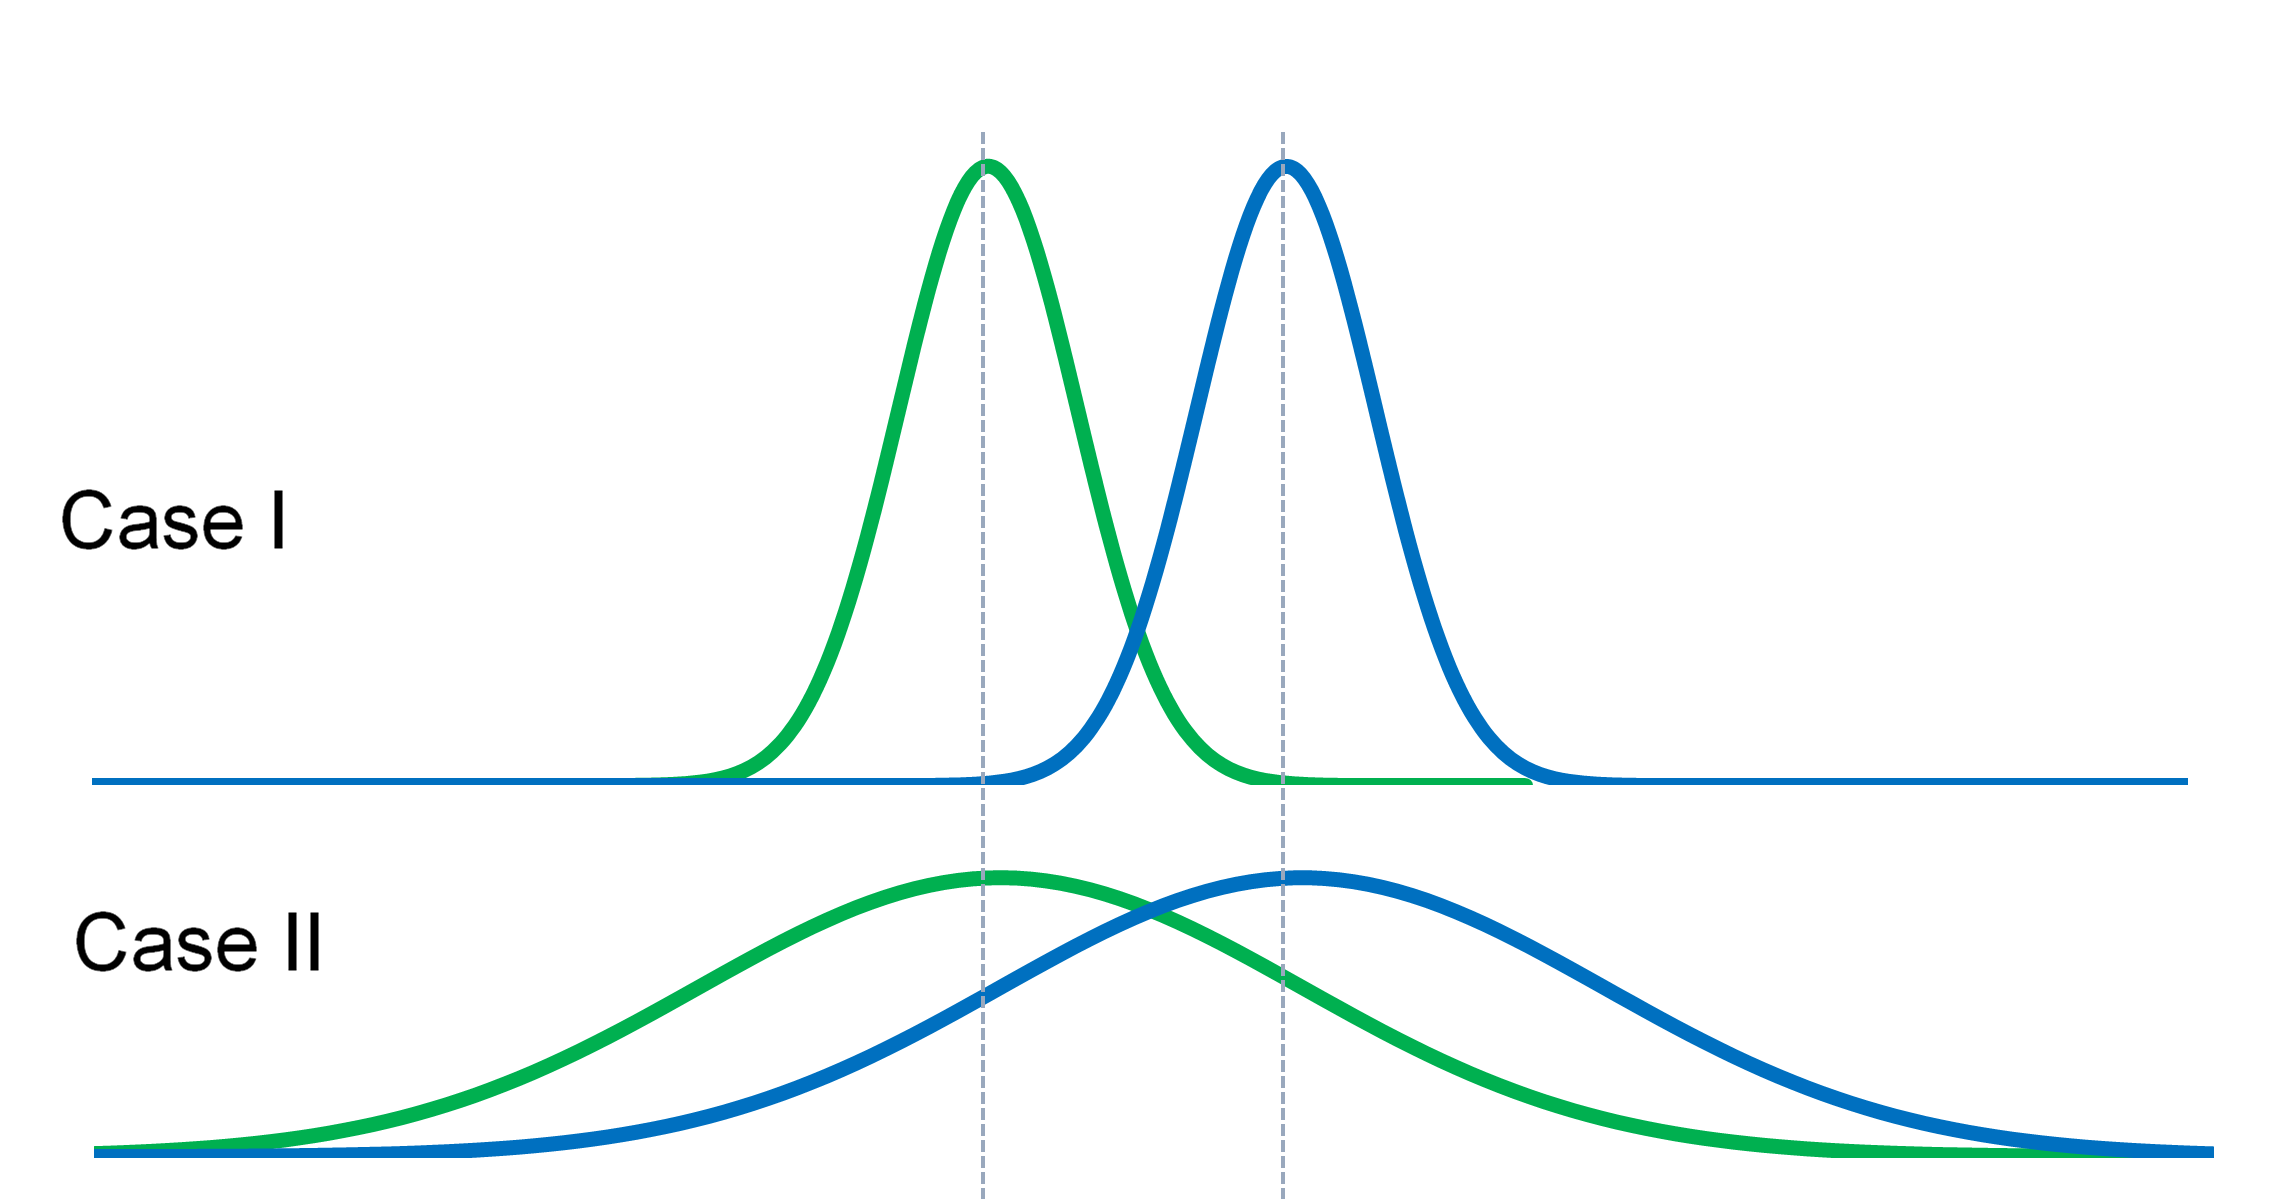

In [ ]:
# Создание препроцессора
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Преобразование данных
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Имена признаков
feature_names = preprocessor.get_feature_names_out()

# Преобразуем разреженную матрицу в плотную и создаем DataFrame
X_train_df = pd.DataFrame(
    X_train_transformed.toarray(),
    columns=feature_names
)
X_test_df = pd.DataFrame(
    X_test_transformed.toarray(),
    columns=feature_names
)

# Вычисление t-статистики для каждого признака
def calculate_t_statistic(X, y):
    y = y.values
    class_0 = (y == 0)
    class_1 = (y == 1)

    t_stats = []
    for col in X.columns:
        # Средние и стандартные отклонения
        mu_0 = X.loc[class_0, col].mean()
        mu_1 = X.loc[class_1, col].mean()

        std_0 = X.loc[class_0, col].std()
        std_1 = X.loc[class_1, col].std()

        n_0 = sum(class_0)
        n_1 = sum(class_1)

        # Обходим деление на 0
        if std_0 == 0 or std_1 == 0:
            t_stat = 0
        else:
            numerator = abs(mu_1 - mu_0)
            denominator = np.sqrt((n_1*std_1**2 + n_0*std_0**2) / (n_1 + n_0))
            t_stat = numerator / denominator if denominator != 0 else 0

        t_stats.append(t_stat)

    return pd.Series(t_stats, index=X.columns)

# Вычисляем t-статистику
start_time = time.time()
t_statistics = calculate_t_statistic(X_train_df, y_train)
selection_time = time.time() - start_time

# Выбор топ-40 признаков
top_40_features = t_statistics.nlargest(40).index

# Обучение на отобранных признаках
model = LogisticRegression(random_state=777, max_iter=3000)
start_train_time = time.time()
model.fit(X_train_df[top_40_features], y_train)
train_time = time.time() - start_train_time

# Оценка качества
y_proba = model.predict_proba(X_test_df[top_40_features])[:, 1]
auc_pr = average_precision_score(y_test, y_proba)

print(f"AUC-PR: {auc_pr:.4f}")
print(f"Время отбора признаков: {selection_time:.2f} сек")
print(f"Время обучения: {train_time:.2f} сек")
print("Топ-5 признаков по t-статистике:")
print(t_statistics.nlargest(5))

AUC-PR: 0.7618
Время отбора признаков: 1.93 сек
Время обучения: 31.59 сек
Топ-5 признаков по t-статистике:
cat__marital-status_ Married-civ-spouse    1.158121
cat__relationship_ Husband                 1.021854
remainder__education-num                   0.832258
cat__marital-status_ Never-married         0.784364
remainder__age                             0.572230
dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### __Задание 10. Методы-обёртки__ (0.5 балла)

Третий из рассматриваемых нами методов работает следующим образом: мы используем жадный метод удаления признаков: на каждом шаге убираем тот признак, который меньше всего влияет на качество модели. Продолжаем так, пока не останется 40 признаков или пока качество не начнет сильно падать.

Важно: оцениваем качество не на тестовой выборке, чтобы избежать переобучения. Для этого делим обучающую выборку на две части: на одной обучаем модель без одного признака, на другой - проверяем качество. Тестовую выборку используем только для финальной проверки.

**Пример:** Предположим, у нас есть модель с признаками A, B, C, D. Сначала убираем признак A, обучаем модель на B, C, D и проверяем качество. Затем возвращаем A, убираем B и так далее. Если оказалось, что без признака C качество выше всего, убираем C навсегда. Продолжаем, пока не останется 40 признаков.

После отбора 40 признаков оцениваем качество на тестовой выборке и замеряем время, затраченное на отбор.


In [ ]:
# train (50%), val (20%), test (30%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2857, random_state=777, stratify=y_temp)

# Препроцессинг
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Настройки модели
model_config = {
    'penalty': 'l2',
    'solver': 'lbfgs',
    'max_iter': 1000,
    'random_state': 777
}

# Отбор признаков
selected_features = list(feature_names)
target_count = 40

print(f"Начало отбора. Признаков: {len(selected_features)}")

while len(selected_features) > target_count:
    mask = np.isin(feature_names, selected_features)

    # Обучение модели на текущих признаках
    model = LogisticRegression(**model_config)
    model.fit(X_train_prep[:, mask], y_train)

    # Определение наименее значимого признака
    coefficients = model.coef_[0]
    min_abs_coeff_idx = np.abs(coefficients).argmin()
    worst_feature = selected_features.pop(min_abs_coeff_idx)

    print(f"Удален: {worst_feature}. Осталось: {len(selected_features)}. Коэффициент: {coefficients[min_abs_coeff_idx]:.4f}")

# Финальная оценка
final_mask = np.isin(feature_names, selected_features)
final_model = LogisticRegression(**model_config)
final_model.fit(X_train_prep[:, final_mask], y_train)

y_proba_test = final_model.predict_proba(X_test_prep[:, final_mask])[:, 1]
test_auc_pr = average_precision_score(y_test, y_proba_test)

print("\nИтоговые результаты:")
print(f"Финальный AUC-PR на тесте: {test_auc_pr:.4f}")
print(f"Отобрано признаков: {len(selected_features)}")
print("Топ-5 признаков по важности:")
importances = pd.Series(final_model.coef_[0], index=selected_features)
print(importances.abs().nlargest(5))

Начало отбора. Признаков: 108
Удален: cat__native-country_ Poland. Осталось: 107. Коэффициент: 0.0026
Удален: cat__native-country_ Holand-Netherlands. Осталось: 106. Коэффициент: -0.0112
Удален: cat__native-country_ Thailand. Осталось: 105. Коэффициент: 0.0142
Удален: cat__sex_ Male. Осталось: 104. Коэффициент: -0.0146
Удален: cat__native-country_ Honduras. Осталось: 103. Коэффициент: -0.0174
Удален: cat__relationship_ Not-in-family. Осталось: 102. Коэффициент: -0.0356
Удален: cat__occupation_ Adm-clerical. Осталось: 101. Коэффициент: 0.0315
Удален: cat__race_ Asian-Pac-Islander. Осталось: 100. Коэффициент: 0.0246
Удален: cat__workclass_ Private. Осталось: 99. Коэффициент: 0.0415
Удален: cat__workclass_ Self-emp-inc. Осталось: 98. Коэффициент: 0.0362
Удален: cat__native-country_ Laos. Осталось: 97. Коэффициент: 0.0466
Удален: cat__education_ Some-college. Осталось: 96. Коэффициент: -0.0497
Удален: cat__education_ Assoc-voc. Осталось: 95. Коэффициент: 0.0039
Удален: cat__education_ 9th.

Стоит отметить, что с помощью такого метода можно пойти и в обратную сторону. Попробуйте _добавлять_ по одному самому полезному признаку в выборку до тех пор, пока не наберется 40 штук. Найдется ли порог, при котором добавление следующих признаков будет только ухудшать качество модели?

In [ ]:
# Препроцессинг
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

X_train_sparse = preprocessor.fit_transform(X_train)
X_test_sparse = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Инициализация
model_config = {
    'penalty': 'l2',
    'solver': 'lbfgs',
    'max_iter': 300,
    'tol': 1e-2,
    'random_state': 777,
    'n_jobs': -1
}

# Прямой отбор признаков
target_features = 40
selected_features = []
remaining_features = list(feature_names)
best_scores = []
stagnation_counter = 0
stagnation_limit = 3

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_sparse,
    y_train,
    test_size=0.15,
    random_state=777,
    stratify=y_train
)

print("Начинаем прямой отбор признаков...")
while len(selected_features) < target_features and remaining_features:
    scores = {}

    for feature in remaining_features:
        current_features = selected_features + [feature]
        feature_indices = np.isin(feature_names, current_features)

        # Обучение
        model = LogisticRegression(**model_config)
        model.fit(X_train_sub[:, feature_indices], y_train_sub)
        y_proba = model.predict_proba(X_val[:, feature_indices])[:, 1]
        score = average_precision_score(y_val, y_proba)
        scores[feature] = score

    best_feature = max(scores, key=scores.get)
    best_score = scores[best_feature]

    if len(best_scores) > 0 and best_score < best_scores[-1]:
        stagnation_counter += 1
        print(f"Предупреждение: Качество снизилось! Счет={best_score:.4f}")
    else:
        stagnation_counter = 0

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    best_scores.append(best_score)

    print(f"Добавлен признак {best_feature}. Всего: {len(selected_features)}/{target_features} | AUC-PR: {best_score:.4f}")

    if stagnation_counter >= stagnation_limit:
        print("Ранняя остановка: Качество перестало улучшаться")
        break

# Финальная оценка
if len(selected_features) < target_features:
    print(f"Внимание: Остановлено на {len(selected_features)} признаках из-за стагнации")

final_indices = np.isin(feature_names, selected_features)
final_model = LogisticRegression(**model_config)
final_model.fit(X_train_sparse[:, final_indices], y_train)

y_proba = final_model.predict_proba(X_test_sparse[:, final_indices])[:, 1]
final_auc_pr = average_precision_score(y_test, y_proba)

print("\nИтоговые результаты:")
print(f"Финальный AUC-PR: {final_auc_pr:.4f}")
print(f"Отобрано признаков: {len(selected_features)}")
print("Топ-5 признаков по важности:")
importances = pd.Series(final_model.coef_[0], index=selected_features)
print(importances.abs().nlargest(5))

Начинаем прямой отбор признаков...
Добавлен признак num__education-num. Всего: 1/40 | AUC-PR: 0.4450
Добавлен признак cat__marital-status_ Married-civ-spouse. Всего: 2/40 | AUC-PR: 0.6335
Добавлен признак num__capital-gain. Всего: 3/40 | AUC-PR: 0.7017
Добавлен признак num__age. Всего: 4/40 | AUC-PR: 0.7317
Добавлен признак num__capital-loss. Всего: 5/40 | AUC-PR: 0.7411
Добавлен признак cat__occupation_ Exec-managerial. Всего: 6/40 | AUC-PR: 0.7463
Добавлен признак num__hours-per-week. Всего: 7/40 | AUC-PR: 0.7518
Добавлен признак cat__workclass_ Self-emp-not-inc. Всего: 8/40 | AUC-PR: 0.7555
Добавлен признак cat__marital-status_ Never-married. Всего: 9/40 | AUC-PR: 0.7579
Добавлен признак cat__occupation_ Other-service. Всего: 10/40 | AUC-PR: 0.7596
Добавлен признак cat__occupation_ Prof-specialty. Всего: 11/40 | AUC-PR: 0.7609
Добавлен признак cat__workclass_ Local-gov. Всего: 12/40 | AUC-PR: 0.7621
Добавлен признак cat__occupation_ Farming-fishing. Всего: 13/40 | AUC-PR: 0.7629
Доб

Давайте подведём итоги по отбору признаков. Назовите преимущества и недостатки каждого из методов. Какой метод привёл к наилучшему качеству?

**Ответ:** Отбор признаков по t-статистике (AUC-PR 0.7618) оказался наиболее эффективным, так как учитывает статистическую значимость связи каждого признака с целевой переменной. Результаты показывают, что масштабирование числовых признаков (StandardScaler) критически важно для линейных моделей, так как улучшает сходимость и качество (AUC-PR 0.7326 против 0.6867 без масштабирования).  Жадное добавление (AUC-PR 0.7530) немного превзошло удаление (0.7385), возможно, потому, что модель начинает оценку сразу с лучших признаков

# Часть 4. Оценка экономического эффекта (1 балл)



В этой части мы сосредоточимся на задачах, которые часто встречаются на практике (помимо рекурсивного обхода`json` и перекладывания`.yml`файлов, разумеется):

- Создадим несколько специализированных метрик качества.
- Настроим модель так, чтобы максимизировать прибыль.
- Оценим потенциальный доход от использования модели.

Для простоты введем некоторые упрощения. Напомним, что выручка - это сумма денег, полученная от клиентов, а прибыль - это выручка за вычетом расходов, таких как зарплата и другие затраты.


#### __Задание 11. Прогноз по доходам и расходам__ (0.5 балла)

В этой части мы будем работать с данными [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing). Этот датасет содержит информацию о банковском телефонном маркетинге.

__Объектом__ здесь является телефонный звонок потенциальному клиенту с предложением некоторой услуги (утверждается, что это краткосрочный депозит). В качестве признакового описания используются характеристики клиента (образование, брак и т.д.), данные о звонке и различные экономические индикаторы - более подробная информация представлена в файле `bank-additional-names.txt`.
__Целевая переменная__ - ответ клиента (согласился ли он открыть депозит?)

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
!unzip bank-additional.zip
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

--2025-04-21 16:45:07--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank-additional.zip.1’

bank-additional.zip     [   <=>              ] 434.15K   666KB/s    in 0.7s    

2025-04-21 16:45:09 (666 KB/s) - ‘bank-additional.zip.1’ saved [444572]

Archive:  bank-additional.zip
replace bank-additional/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
X = df.drop(columns=['duration', 'y'])
y = (df.y == 'yes')

В этой части не нужно делить выборку - мы будем использовать кросс-валидацию.  Используйте 5 фолдов, сделайте `shuffle=True, random_state=555`. По кросс-валидации у вас получится 5 вариантов обучающей и тестовой выборки.

In [ ]:
# Делим выборку на 5 фолдов
folds = KFold(n_splits=5, shuffle=True, random_state=555)

Обучите логистическую регрессию на каждой обучающей выборке (воспользуйтесь one-hot для категориальных признаков и `StandardScaler` для числовых, гиперпараметры по умолчанию) и сделайте предсказания для соответствующих тестовых выборок.

In [ ]:
# Признаки
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numeric_features = X.select_dtypes(include=['number']).columns

# Препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Pipeline: предобработка + модель
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

auc_pr_scores = []
y_probs_list = []
y_true_list = []

for train_index, test_index in folds.split(X):
    # Разделение данных
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Обучение модели
    model.fit(X_train, y_train)

    # Получение вероятностей принадлежности к классу 1
    y_proba = model.predict_proba(X_test)[:, 1]

    # Вычисление AUC-PR
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = auc(recall, precision)
    auc_pr_scores.append(auc_pr)

    # Сохранение результатов
    y_probs_list.append(y_proba)
    y_true_list.append(y_test.values)

# Вывод результатов
print(f"AUC-PR для каждого фолда: {[round(score, 4) for score in auc_pr_scores]}")
print(f"Среднее AUC-PR: {sum(auc_pr_scores)/len(auc_pr_scores):.4f}")

AUC-PR для каждого фолда: [np.float64(0.4399), np.float64(0.477), np.float64(0.4354), np.float64(0.4609), np.float64(0.4523)]
Среднее AUC-PR: 0.4531


Допустим, работники вашего колл-центра получают за один звонок клиенту 1 доллар. При согласии клиента на предлагаемые условия он принесет в банк 10 долларов. Предположим, что всем положительным прогнозам ваши сотрудники решили позвонить. Посчитайте на всех тестовых выборках выручку и усредните. Также вычислите стандартное отклонение.
- Сколько денег вы в среднем заработаете?
- Сколько из заработанных денег придётся отдать операторам вашего колл-центра?

In [ ]:
profits = []
total_revenues = []
total_costs = []
total_calls = []
total_tp = []

for i in range(len(y_probs_list)):
    y_proba = y_probs_list[i]
    y_true = y_true_list[i]

    y_pred = (y_proba >= 0.5).astype(int)
    calls = (y_pred == 1).sum()               # Количество звонков
    total_calls.append(calls)

    tp = ((y_pred == 1) & (y_true == 1)).sum() # Количество истинно положительных (True Positives)
    total_tp.append(tp)

    # Финансовые показатели
    revenue = tp * 10  # Выручка: 10$ за каждого согласившегося
    cost = calls * 1   # Расходы: 1$ за каждый звонок
    profit = revenue - cost

    # Результаты
    profits.append(profit)
    total_revenues.append(revenue)
    total_costs.append(cost)

# Агрегированные результаты
mean_profit = np.mean(profits)
std_profit = np.std(profits)
sum_revenue = sum(total_revenues)
sum_cost = sum(total_costs)
cost_percentage = (sum_cost / sum_revenue * 100) if sum_revenue != 0 else 0

print(f"Средняя прибыль: {mean_profit:.2f}$")
print(f"Стандартное отклонение прибыли: {std_profit:.2f}$")
print(f"Суммарная выручка: {sum_revenue:.2f}$")
print(f"Суммарные расходы на операторов: {sum_cost}$")
print(f"Доля расходов от выручки: {cost_percentage:.2f}%")

Средняя прибыль: 1796.80$
Стандартное отклонение прибыли: 95.40$
Суммарная выручка: 10580.00$
Суммарные расходы на операторов: 1596$
Доля расходов от выручки: 15.09%


Внесем некоторую долю случайности. Пусть теперь согласный на условия клиент будет приносить не 10 долларов, а случайную величину, равномерно распределенную в интервале $[0;20)$. Проделайте все те же самые действия. Для имитации реальной ситуации **НЕ** фиксируйте `random_seed` при подсчете выручки с клиента. Что получилось?

In [ ]:
# Делим выборку на 5 фолдов
folds = KFold(n_splits=5, shuffle=True)

# Признаки
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numeric_features = X.select_dtypes(include=['number']).columns

# Препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Pipeline: предобработка + модель
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

auc_pr_scores = []
y_probs_list = []
y_true_list = []

for train_index, test_index in folds.split(X):
    # Разделение данных
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Обучение модели
    model.fit(X_train, y_train)

    # Получение вероятностей принадлежности к классу 1
    y_proba = model.predict_proba(X_test)[:, 1]

    # Вычисление AUC-PR
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = auc(recall, precision)
    auc_pr_scores.append(auc_pr)

    # Сохранение результатов
    y_probs_list.append(y_proba)
    y_true_list.append(y_test.values)

In [ ]:
profits = []
total_revenues = []
total_costs = []
total_calls = []
total_tp = []

for i in range(len(y_probs_list)):
    y_proba = y_probs_list[i]
    y_true = y_true_list[i]


    y_pred = (y_proba >= 0.5).astype(int)
    calls = (y_pred == 1).sum()
    total_calls.append(calls)

    tp_mask = (y_pred == 1) & (y_true == 1) # True Positives
    tp = tp_mask.sum()
    total_tp.append(tp)

    # Случайная выручка: равномерное распределение [0, 20) для каждого TP
    revenue = np.random.uniform(0, 20, size=tp).sum()

    cost = calls * 1     # Расходы на звонки

    # Прибыль
    profit = revenue - cost

    # Результаты
    profits.append(profit)
    total_revenues.append(revenue)
    total_costs.append(cost)

# Агрегация
mean_profit = np.mean(profits)
std_profit = np.std(profits)
sum_revenue = sum(total_revenues)
sum_cost = sum(total_costs)
cost_percentage = (sum_cost / sum_revenue * 100) if sum_revenue != 0 else 0

print(f"Средняя прибыль: {mean_profit:.2f}$")
print(f"Стандартное отклонение: {std_profit:.2f}$")
print(f"Суммарная выручка: {sum_revenue:.2f}$")
print(f"Суммарные расходы: {sum_cost}$")
print(f"Доля расходов: {cost_percentage:.2f}%")

Средняя прибыль: 1824.26$
Стандартное отклонение: 162.26$
Суммарная выручка: 10717.32$
Суммарные расходы: 1596$
Доля расходов: 14.89%


Увееличилась средняя прибыль, общая прибыль  и при этом выросло стандартное отклонение. Доля расходов упала. Показатели могут получиться хуже без фиксирования рандома. В большинстве случаев прибыль растет

Настройте по кросс-валидации коэффициент регуляризации модели для максимизации прибыли (считайте как случайную величину выше). Удалось ли получить какой-то выигрыш? При каком коэффициенте регуляризациии прибыль максимальна? Постройте график зависимости ожидаемой прибыли от коэффициента, укажите стандартные отклонения (вам поможет `plt.errorbar`, [пример](https://jakevdp.github.io/PythonDataScienceHandbook/04.03-errorbars.html)).

<ipython-input-94-636c4d21864f>:66: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(


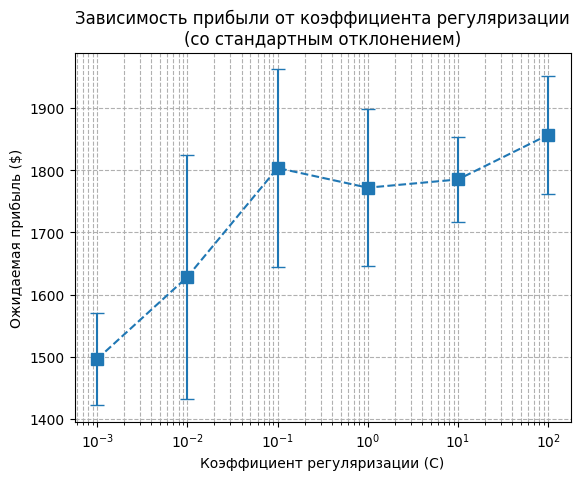

Максимальная средняя прибыль: $1856.75 достигается при C = 100.0


In [ ]:
folds = KFold(n_splits=5, shuffle=True, random_state=555)

# Признаки
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numeric_features = X.select_dtypes(include=['number']).columns

# Создание преобразований для признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Список коэффициентов регуляризации для перебора (C)
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_results = []


for C in C_values:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(C=C, max_iter=1000))
    ])

    fold_profits = []

    for train_index, test_index in folds.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Обучение модели
        model.fit(X_train, y_train)

        # Предсказание вероятностей
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)

        # True Positives
        tp_mask = (y_pred == 1) & (y_test == 1)
        tp = tp_mask.sum()

        # Случайная выручка
        revenue = np.random.uniform(0, 20, size=tp).sum()
        cost = (y_pred == 1).sum() * 1
        profit = revenue - cost

        fold_profits.append(profit)

    # Результаты для текущего C
    mean_profit = np.mean(fold_profits)
    std_profit = np.std(fold_profits)
    cv_results.append({
        'C': C,
        'mean_profit': mean_profit,
        'std_profit': std_profit
    })

# Преобразование результатов в DataFrame
results_df = pd.DataFrame(cv_results)

# Нахождение оптимального C
best_C = results_df.loc[results_df['mean_profit'].idxmax()]['C']
max_profit = results_df['mean_profit'].max()

# Визуализация
plt.errorbar(
    x=results_df['C'],
    y=results_df['mean_profit'],
    yerr=results_df['std_profit'],
    fmt='o',
    capsize=5,
    markersize=8,
    linestyle='--',
    marker='s'
)
plt.xscale('log')
plt.xlabel('Коэффициент регуляризации (C)')
plt.ylabel('Ожидаемая прибыль ($)')
plt.title('Зависимость прибыли от коэффициента регуляризации\n(со стандартным отклонением)')
plt.grid(True, which="both", ls="--")
plt.show()

print(f"Максимальная средняя прибыль: ${max_profit:.2f} достигается при C = {best_C}")

Попробуйте запустить перебор несколько раз. Находится ли каждый раз один и тот же "лучший" коэффициент? Присутствует ли какая-то закономерность? Какие вы можете сделать из этого выводы?

Запуск 1/10
Запуск 2/10
Запуск 3/10
Запуск 4/10
Запуск 5/10
Запуск 6/10
Запуск 7/10
Запуск 8/10
Запуск 9/10
Запуск 10/10


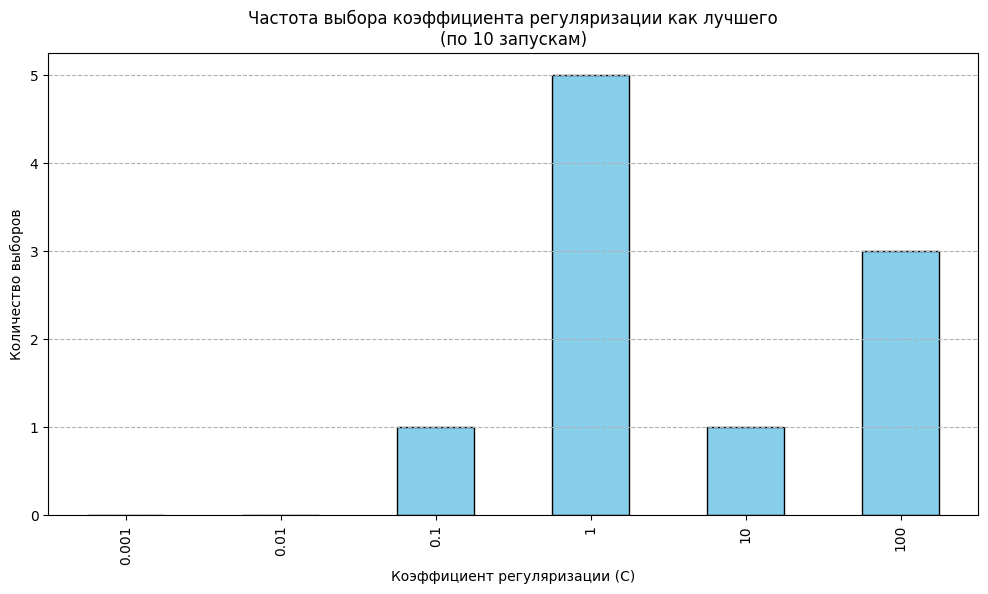

Средние результаты по всем запускам:
         mean_profit  std_profit
C                               
0.001    1496.298599  116.676649
0.010    1679.871719  157.493689
0.100    1752.153422  140.489249
1.000    1802.275430  116.098756
10.000   1788.342361  109.855787
100.000  1799.869253  101.900361


In [ ]:
folds = KFold(n_splits=5, shuffle=True, random_state=555)

n_runs = 10                                   # Количество запусков перебора C
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = []

# Подготовка данных
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numeric_features = X.select_dtypes(include=['number']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Многократный запуск перебора C
for run in range(n_runs):
    print(f"Запуск {run + 1}/{n_runs}")
    cv_results = []

    for C in C_values:
        model = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(C=C, max_iter=1000))
        ])

        fold_profits = []
        kf = KFold(n_splits=5, shuffle=True, random_state=555)

        for train_index, test_index in kf.split(X):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]

            model.fit(X_train, y_train)
            y_proba = model.predict_proba(X_test)[:, 1]
            y_pred = (y_proba >= 0.5).astype(int)

            tp = ((y_pred == 1) & (y_test == 1)).sum()
            revenue = np.random.uniform(0, 20, size=tp).sum()
            cost = (y_pred == 1).sum() * 1
            profit = revenue - cost
            fold_profits.append(profit)

        mean_profit = np.mean(fold_profits)
        std_profit = np.std(fold_profits)
        cv_results.append({
            'run': run,
            'C': C,
            'mean_profit': mean_profit,
            'std_profit': std_profit
        })

    results.append(cv_results)

# Агрегация результатов
all_results = [item for sublist in results for item in sublist]
df_results = pd.DataFrame(all_results)

# Определение лучшего C для каждого запуска
best_C_per_run = df_results.loc[df_results.groupby('run')['mean_profit'].idxmax()][['run', 'C']]
best_C_counts = best_C_per_run['C'].value_counts().reindex(C_values, fill_value=0)

# Визуализация стабильности выбора C
plt.figure(figsize=(12, 6))
best_C_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Частота выбора коэффициента регуляризации как лучшего\n(по {} запускам)'.format(n_runs))
plt.xlabel('Коэффициент регуляризации (C)')
plt.ylabel('Количество выборов')
plt.xticks(ticks=range(len(C_values)), labels=[str(c) for c in C_values])
plt.grid(axis='y', linestyle='--')
plt.show()

# Средняя прибыль и стандартное отклонение по всем запускам
pivot_df = df_results.pivot_table(index='C', values=['mean_profit', 'std_profit'], aggfunc='mean')
print("Средние результаты по всем запускам:")
print(pivot_df)

Получился другой оптимальный параметр C

#### __Задание 12. Ключевая метрика__ (0.5 балла)

Выше мы уже описали примерную экономическую модель вашей задачи. Как вы считаете, что для вашего бизнеса важнее — хороший precision или recall модели? Почему?

**Ответ:** Для  бизнеса важнее хороший precision. Каждый звонок стоит 1 доллар, средняя выручка от клиента 10 долларов при равномерном распределении. Однако из-за случайности выручка может быть даже меньше затрат .
Высокий precision означает, что большинство звонков будут прибыльными, модель реже ошибается в предсказании. Это критически важно, так как убыточные звонки напрямую сокращают прибыль

> Вспомним, что на самом деле логистическая регрессия предсказывает нам вероятности положительного класса для объекта. Возможно, путем настройки __порога бинаризации__ этих вероятностей мы сможем получить какой-то выигрыш?

Проверьте ваши рассуждения выше с помощью настройки порога бинаризации на кросс-валидации для максимизации прибыли. Воспользуйтесь сеткой от 0 до 1 с шагом 0.01. Напомним, что снижение порога дает нам более высокий recall и более низкий precision, и наоборот.

In [ ]:
# Препроцеессинг
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numeric_features = X.select_dtypes(include=['number']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Инициализация модели с лучшим C из предыдущего шага (пример: C=1)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1, max_iter=1000))
])

# Сетка порогов
thresholds = np.arange(0, 1.01, 0.01)
folds = KFold(n_splits=5, shuffle=True, random_state=555)
results = []

for threshold in thresholds:
    fold_profits = []

    for train_index, test_index in folds.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Обучение модели
        model.fit(X_train, y_train)

        # Предсказание вероятностей
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        # Расчет прибыли
        tp = ((y_pred == 1) & (y_test == 1)).sum()
        revenue = np.random.uniform(0, 20, size=tp).sum()
        cost = (y_pred == 1).sum() * 1
        profit = revenue - cost

        fold_profits.append(profit)

    # Сохранение результатов
    mean_profit = np.mean(fold_profits)
    std_profit = np.std(fold_profits)
    results.append({
        'threshold': threshold,
        'mean_profit': mean_profit,
        'std_profit': std_profit
    })

# Преобразование в DataFrame
df_results = pd.DataFrame(results)

# Нахождение оптимального порога
best_row = df_results.loc[df_results['mean_profit'].idxmax()]
optimal_threshold = best_row['threshold']
max_profit = best_row['mean_profit']

print(f"Максимальная средняя прибыль: ${max_profit:.2f} достигается при пороге {optimal_threshold:.2f}")

Максимальная средняя прибыль: $4231.62 достигается при пороге 0.11


Постройте график зависимости прибыли от порога бинаризации, также отметьте на нем стандартные отклонения. Выделите наилучший порог.




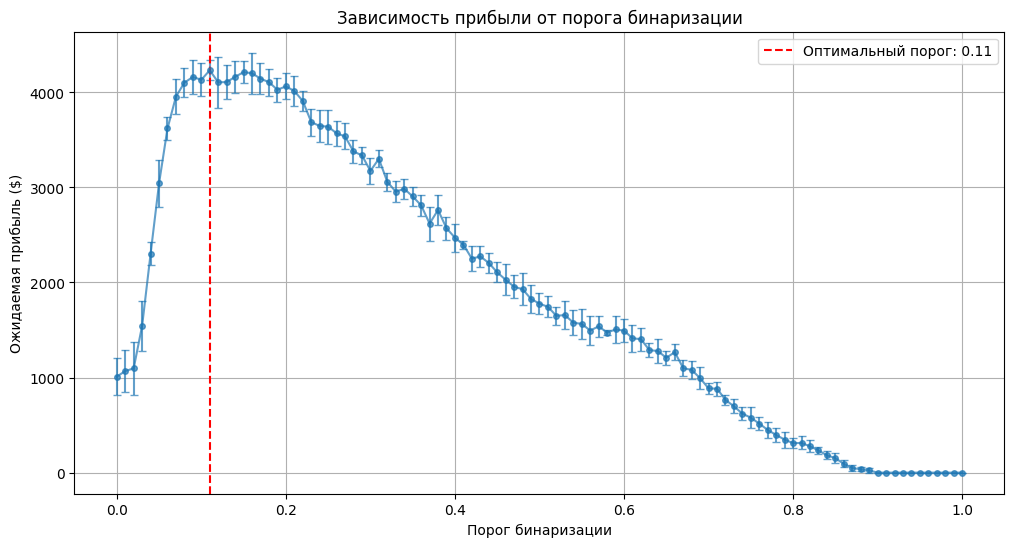

In [ ]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.errorbar(
    x=df_results['threshold'],
    y=df_results['mean_profit'],
    yerr=df_results['std_profit'],
    fmt='o',
    markersize=4,
    linestyle='-',
    alpha=0.7,
    capsize=3
)
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Оптимальный порог: {optimal_threshold:.2f}')
plt.xlabel('Порог бинаризации')
plt.ylabel('Ожидаемая прибыль ($)')
plt.title('Зависимость прибыли от порога бинаризации')
plt.legend()
plt.grid(True)
plt.show()

Каковы значения precision и recall на выбранном пороге? Оцените по кросс-валидации. Также вычислите стандартное отклонение.

In [ ]:
from sklearn.metrics import precision_score, recall_score
# Оптимальный порог из прошлого шага
optimal_threshold = 0.11

# Инициализация модели с лучшими параметрами
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1, max_iter=1000))
])

# Настройки кросс-валидации
folds = KFold(n_splits=5, shuffle=True, random_state=555)

# Списки для хранения метрик
precisions = []
recalls = []

for train_index, test_index in folds.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказание вероятностей и бинаризация
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= optimal_threshold).astype(int)

    # Расчет метрик
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    precisions.append(prec)
    recalls.append(rec)

# Результаты
mean_precision = np.mean(precisions)
std_precision = np.std(precisions)
mean_recall = np.mean(recalls)
std_recall = np.std(recalls)

print(f"Precision: {mean_precision:.2f} ± {std_precision:.2f}")
print(f"Recall: {mean_recall:.2f} ± {std_recall:.2f}")

Precision: 0.34 ± 0.01
Recall: 0.64 ± 0.03
